# Conv1D Autoencoder with SWaT 2020

In [1]:
import os
import glob
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import StandardScaler
from pathlib import Path

In [2]:
clean_folder = Path("../data/clean/SWaT.A7_June2020_clean")
file_paths = sorted(clean_folder.glob("*.csv"))

print("Archivos encontrados:", len(file_paths))
for fp in file_paths:
    print(fp)

Archivos encontrados: 4
..\data\clean\SWaT.A7_June2020_clean\22June2020_1.csv
..\data\clean\SWaT.A7_June2020_clean\22June2020_2.csv
..\data\clean\SWaT.A7_June2020_clean\29June2020_1.csv
..\data\clean\SWaT.A7_June2020_clean\29June2020_2.csv


In [3]:
def load_clean_csv(path):
    df = pd.read_csv(path)
    df["t_stamp"] = pd.to_datetime(df["t_stamp"], errors="coerce")
    df = df.sort_values("t_stamp").reset_index(drop=True)
    return df

In [4]:
files = {fp.stem: load_clean_csv(fp) for fp in file_paths}

print("Número de archivos cargados:", len(files))
for name, df in files.items():
    print(name, df.shape)

Número de archivos cargados: 4
22June2020_1 (14400, 61)
22June2020_2 (3600, 61)
29June2020_1 (7201, 61)
29June2020_2 (7201, 61)


In [5]:
# Eliminar filas completamente vacías en variables del sistema
temp_feature_cols = [c for c in next(iter(files.values())).columns if c != "t_stamp"]

for name in files:
    before = len(files[name])
    files[name] = files[name].dropna(subset=temp_feature_cols, how="all").reset_index(drop=True)
    after = len(files[name])

    if before != after:
        print(f"{name}: se eliminaron {before - after} filas completamente vacías")

29June2020_2: se eliminaron 1 filas completamente vacías


In [6]:
common_cols = sorted(set.intersection(*(set(df.columns) for df in files.values())))
print(f"Número de columnas comunes: {len(common_cols)}")

for name, df in files.items():
    extra = sorted(set(df.columns) - set(common_cols))
    if extra:
        print(f"{name} tiene columnas no comunes: {extra}")

Número de columnas comunes: 61


In [7]:
def plot_sensor_time_series_by_day(files, sensor_col):
    day_groups = {
        "22June2020": ["22June2020_2", "22June2020_1"],
        "29June2020": ["29June2020_1", "29June2020_2"]
    }

    for day, file_list in day_groups.items():
        plt.figure(figsize=(12, 4))

        for fname in file_list:
            if fname in files:
                df = files[fname]
                plt.plot(df["t_stamp"], df[sensor_col], label=fname)

        plt.title(f"{sensor_col} - {day}")
        plt.legend()
        plt.grid(True)
        plt.show()

## Reproducibilidad

In [8]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
os.environ["PYTHONHASHSEED"] = str(SEED)

## Identificación de variables

In [9]:
sample_df = next(iter(files.values()))
all_cols = sample_df.columns.tolist()

timestamp_cols = [c for c in all_cols if c == "t_stamp"]
pv_cols = [c for c in all_cols if c.endswith(".Pv")]
status_cols = [c for c in all_cols if c.endswith(".Status")]
state_cols = [c for c in all_cols if c.startswith("P") and c.endswith("_STATE")]

classified_cols = set(timestamp_cols + pv_cols + status_cols + state_cols)
other_cols = [c for c in all_cols if c not in classified_cols]

feature_cols = pv_cols + status_cols + state_cols
continuous_cols = pv_cols
discrete_cols = status_cols + state_cols

print("Resumen de variables detectadas")
print(f"Timestamp: {len(timestamp_cols)}")
print(f"Sensores continuos (.Pv): {len(pv_cols)}")
print(f"Actuadores discretos (.Status): {len(status_cols)}")
print(f"Estados discretos (_STATE): {len(state_cols)}")
print(f"Otras columnas no clasificadas: {len(other_cols)}")

if timestamp_cols:
    print("\nTimestamp:")
    print(timestamp_cols)

if other_cols:
    print("\nColumnas no clasificadas:")
    print(other_cols)

Resumen de variables detectadas
Timestamp: 1
Sensores continuos (.Pv): 25
Actuadores discretos (.Status): 29
Estados discretos (_STATE): 6
Otras columnas no clasificadas: 0

Timestamp:
['t_stamp']


## Lista de variables

In [10]:
print("\n--- Sensores continuos (.Pv) ---")
print(pv_cols)

print("\n--- Actuadores discretos (.Status) ---")
print(status_cols)

print("\n--- Estados discretos (_STATE) ---")
print(state_cols)

print("\nVariables continuas a escalar:", len(continuous_cols))
print("Variables discretas sin escalar:", len(discrete_cols))


--- Sensores continuos (.Pv) ---
['AIT201.Pv', 'AIT202.Pv', 'AIT203.Pv', 'AIT401.Pv', 'AIT402.Pv', 'AIT501.Pv', 'AIT502.Pv', 'AIT503.Pv', 'AIT504.Pv', 'DPIT301.Pv', 'FIT101.Pv', 'FIT201.Pv', 'FIT301.Pv', 'FIT401.Pv', 'FIT501.Pv', 'FIT502.Pv', 'FIT503.Pv', 'FIT504.Pv', 'FIT601.Pv', 'LIT101.Pv', 'LIT301.Pv', 'LIT401.Pv', 'PIT501.Pv', 'PIT502.Pv', 'PIT503.Pv']

--- Actuadores discretos (.Status) ---
['MV101.Status', 'MV201.Status', 'MV301.Status', 'MV302.Status', 'MV303.Status', 'MV304.Status', 'MV501.Status', 'MV502.Status', 'MV503.Status', 'MV504.Status', 'P101.Status', 'P102.Status', 'P201.Status', 'P202.Status', 'P203.Status', 'P204.Status', 'P205.Status', 'P206.Status', 'P301.Status', 'P302.Status', 'P401.Status', 'P402.Status', 'P403.Status', 'P404.Status', 'P501.Status', 'P502.Status', 'P601.Status', 'P602.Status', 'UV401.Status']

--- Estados discretos (_STATE) ---
['P1_STATE', 'P2_STATE', 'P3_STATE', 'P4_STATE', 'P5_STATE', 'P6_STATE']

Variables continuas a escalar: 25
Variable

In [11]:
summary_rows = []

for name, df in files.items():
    summary_rows.append({
        "file": name,
        "rows": len(df),
        "cols": len(df.columns),
        "start_time": df["t_stamp"].min() if "t_stamp" in df.columns else None,
        "end_time": df["t_stamp"].max() if "t_stamp" in df.columns else None,
        "missing_total": df.isna().sum().sum()
    })

summary_df = pd.DataFrame(summary_rows)
summary_df

,file,rows,cols,start_time,end_time,missing_total
0,22June2020_1,14400,61,2020-06-22 10:00:00,2020-06-22 14:01:10.990,0
1,22June2020_2,3600,61,2020-06-22 09:00:00,2020-06-22 09:59:59.000,0
2,29June2020_1,7201,61,2020-06-29 10:00:00,2020-06-29 12:00:00.000,0
3,29June2020_2,7200,61,2020-06-29 13:30:00,2020-06-29 15:29:59.000,0


In [12]:
for name, df in files.items():
    print(f"\n===== {name} =====")
    print("NaN en Pv:")
    print(df[pv_cols].isna().sum().sort_values(ascending=False).head(10))

    print("\nNaN en Status/STATE:")
    print(df[status_cols + state_cols].isna().sum().sort_values(ascending=False).head(10))


===== 22June2020_1 =====
NaN en Pv:
AIT201.Pv     0
AIT202.Pv     0
AIT203.Pv     0
AIT401.Pv     0
AIT402.Pv     0
AIT501.Pv     0
AIT502.Pv     0
AIT503.Pv     0
AIT504.Pv     0
DPIT301.Pv    0
dtype: int64

NaN en Status/STATE:
MV101.Status    0
MV201.Status    0
MV301.Status    0
MV302.Status    0
MV303.Status    0
MV304.Status    0
MV501.Status    0
MV502.Status    0
MV503.Status    0
MV504.Status    0
dtype: int64

===== 22June2020_2 =====
NaN en Pv:
AIT201.Pv     0
AIT202.Pv     0
AIT203.Pv     0
AIT401.Pv     0
AIT402.Pv     0
AIT501.Pv     0
AIT502.Pv     0
AIT503.Pv     0
AIT504.Pv     0
DPIT301.Pv    0
dtype: int64

NaN en Status/STATE:
MV101.Status    0
MV201.Status    0
MV301.Status    0
MV302.Status    0
MV303.Status    0
MV304.Status    0
MV501.Status    0
MV502.Status    0
MV503.Status    0
MV504.Status    0
dtype: int64

===== 29June2020_1 =====
NaN en Pv:
AIT201.Pv     0
AIT202.Pv     0
AIT203.Pv     0
AIT401.Pv     0
AIT402.Pv     0
AIT501.Pv     0
AIT502.Pv     0
A

## Diagnóstico de continuidad temporal

En esta sección se revisa si existen saltos temporales relevantes entre muestras consecutivas.
Esto permite identificar discontinuidades reales del dataset y evitar la construcción de ventanas
que mezclen segmentos no consecutivos del proceso.

## Visualización temporal de sensores clave

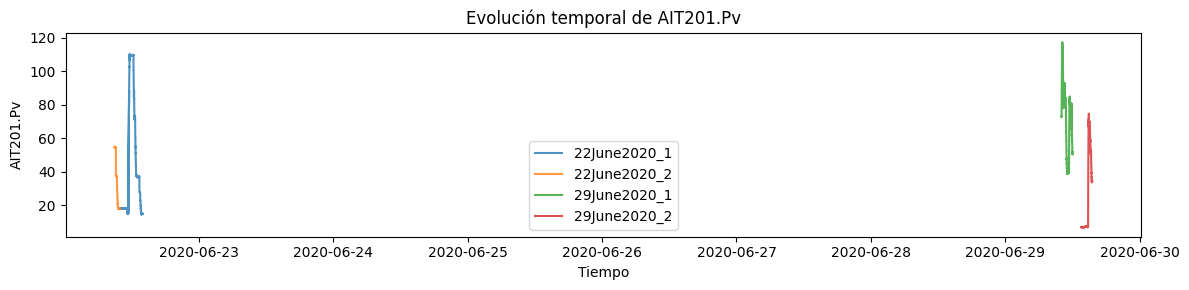

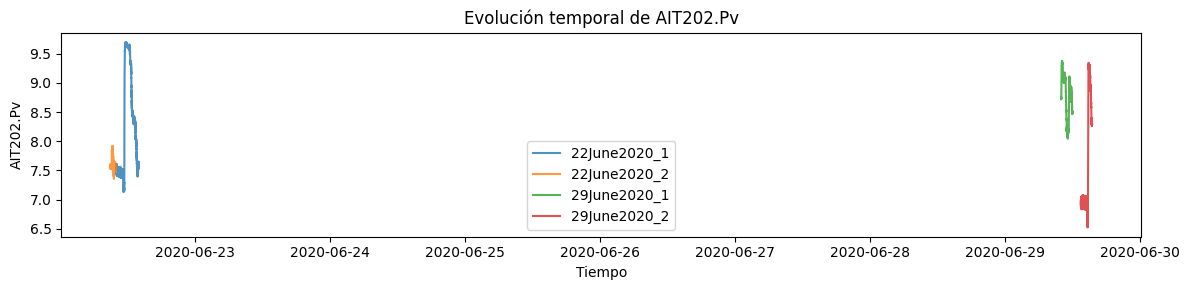

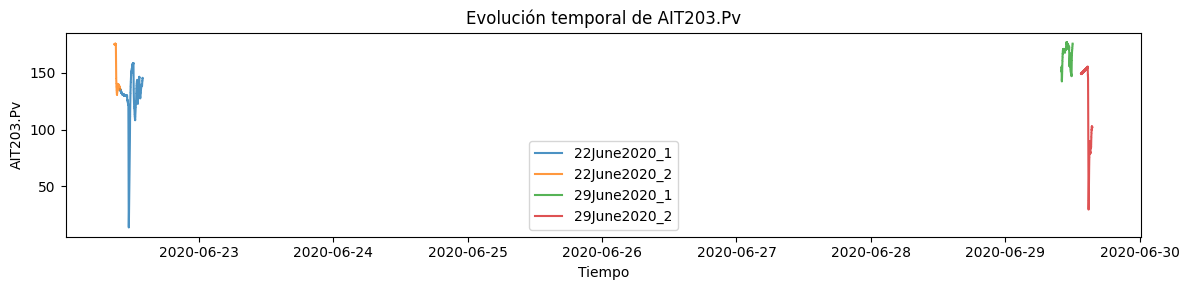

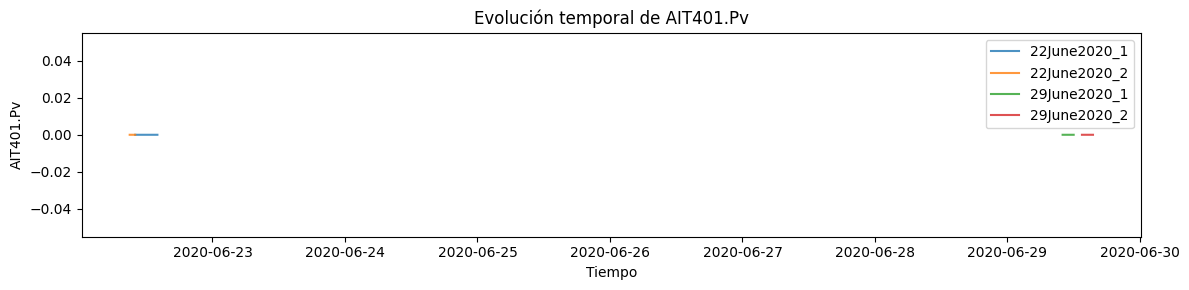

In [13]:
example_pv = ["AIT201.Pv", "AIT202.Pv", "AIT203.Pv", "AIT401.Pv"]

for col in example_pv:
    plt.figure(figsize=(12, 3))
    for name, df in files.items():
        plt.plot(df["t_stamp"], df[col], label=name, alpha=0.8)
    plt.title(f"Evolución temporal de {col}")
    plt.xlabel("Tiempo")
    plt.ylabel(col)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [14]:
def plot_sensor_time_series_by_day(files, sensor_col):
    day_groups = {
        "22June2020": ["22June2020_2", "22June2020_1"],
        "29June2020": ["29June2020_1", "29June2020_2"]
    }

    for day, file_list in day_groups.items():
        plt.figure(figsize=(12, 4))

        for fname in file_list:
            if fname in files:
                df = files[fname].sort_values("t_stamp")
                plt.plot(df["t_stamp"], df[sensor_col], label=fname, linewidth=1.2)

        plt.title(f"{sensor_col} - {day}")
        plt.xlabel("Tiempo")
        plt.ylabel(sensor_col)
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()

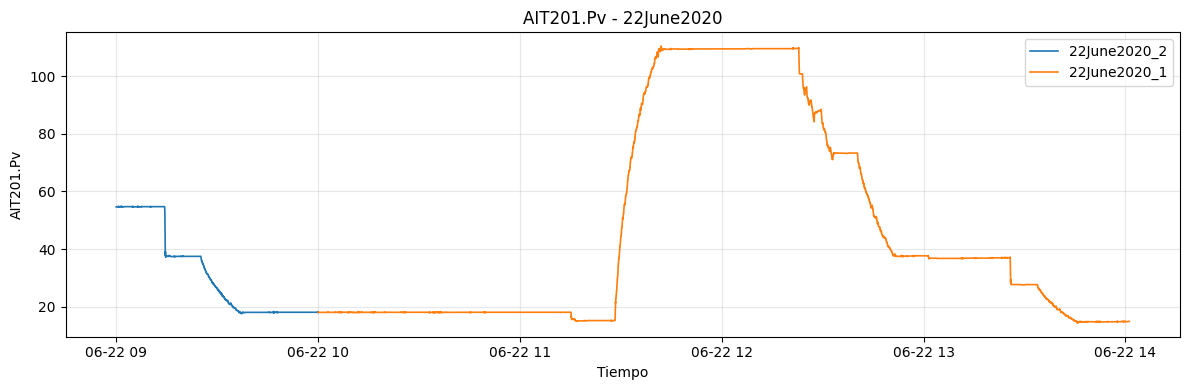

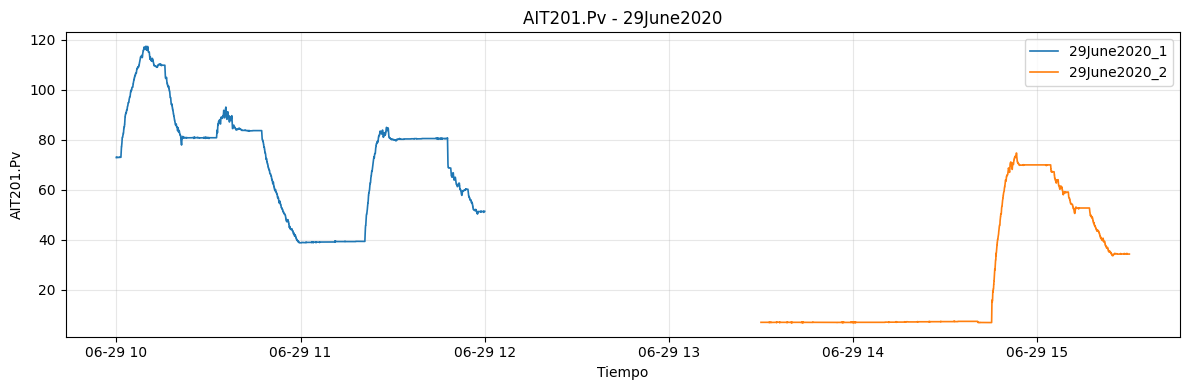

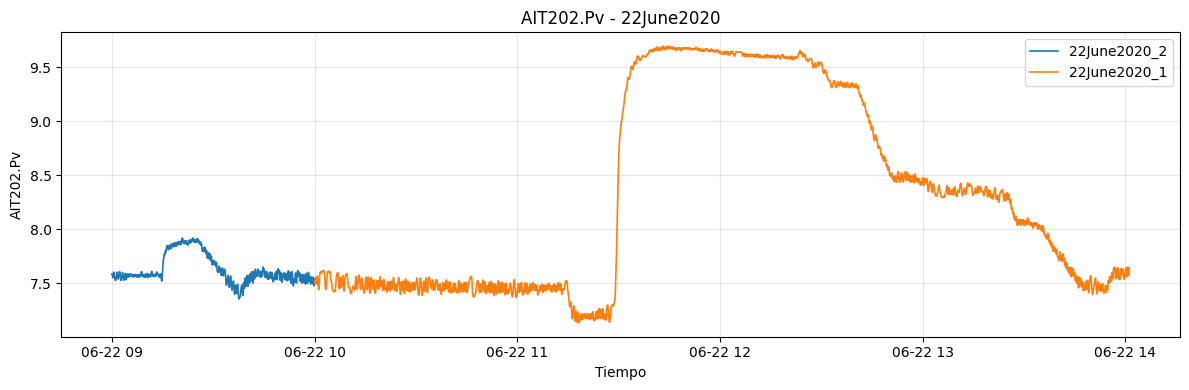

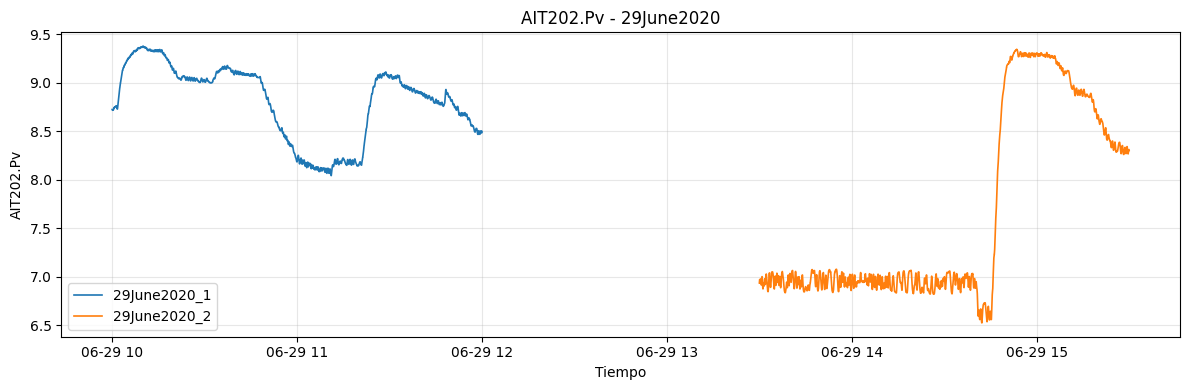

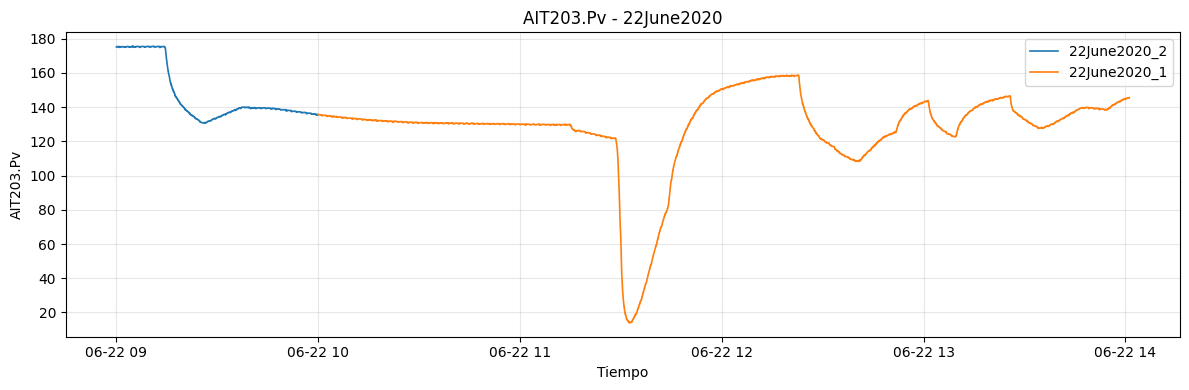

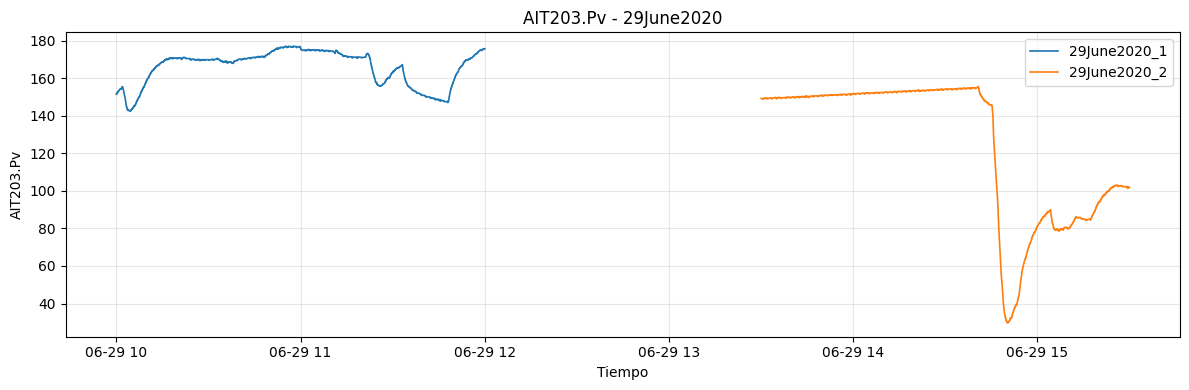

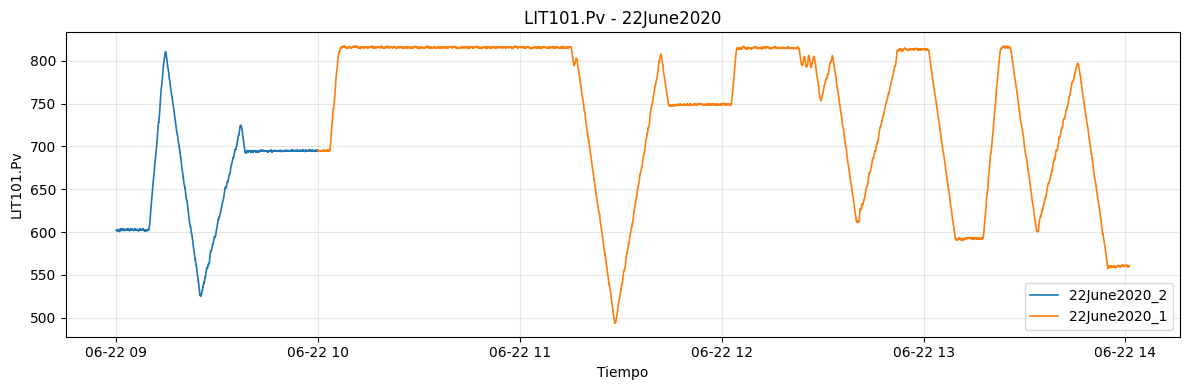

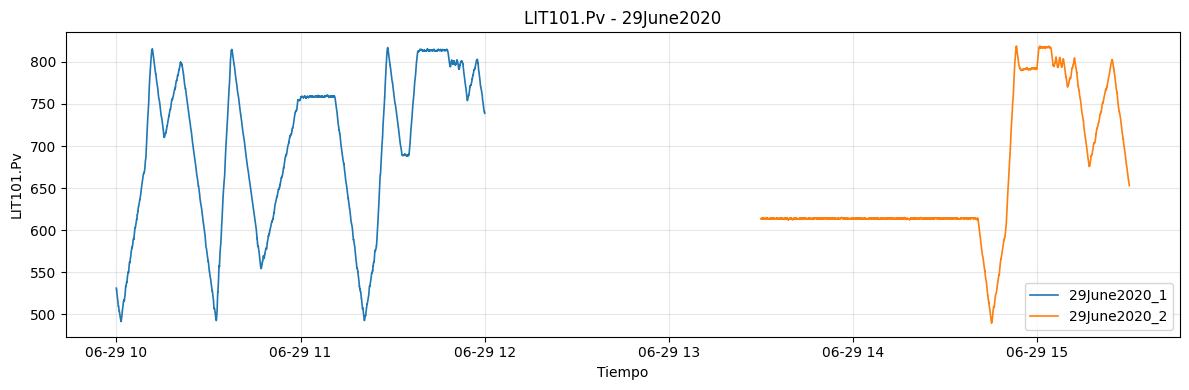

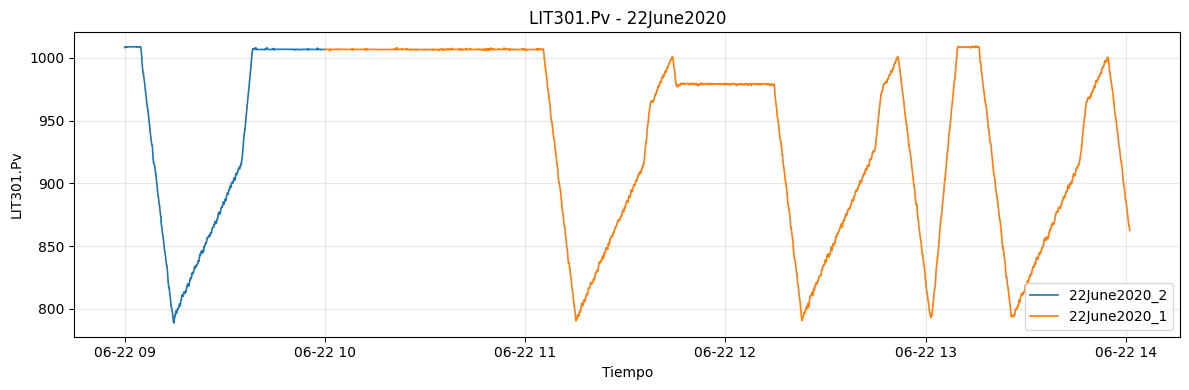

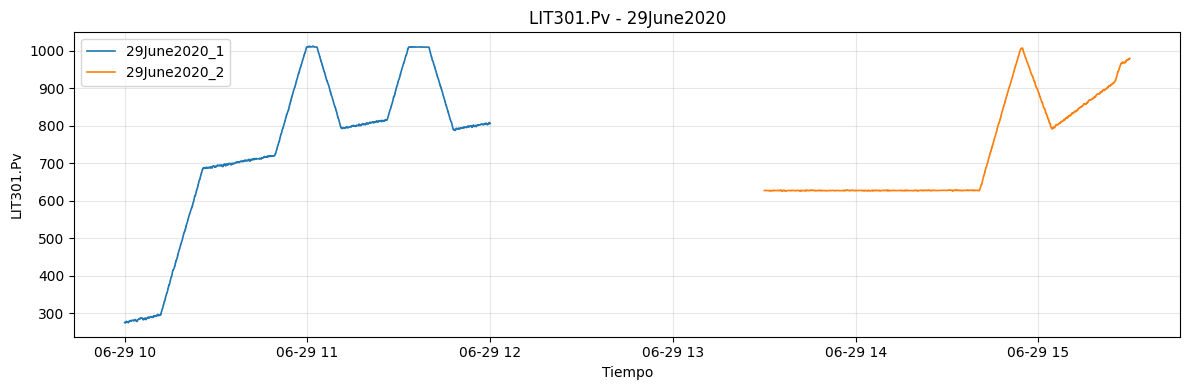

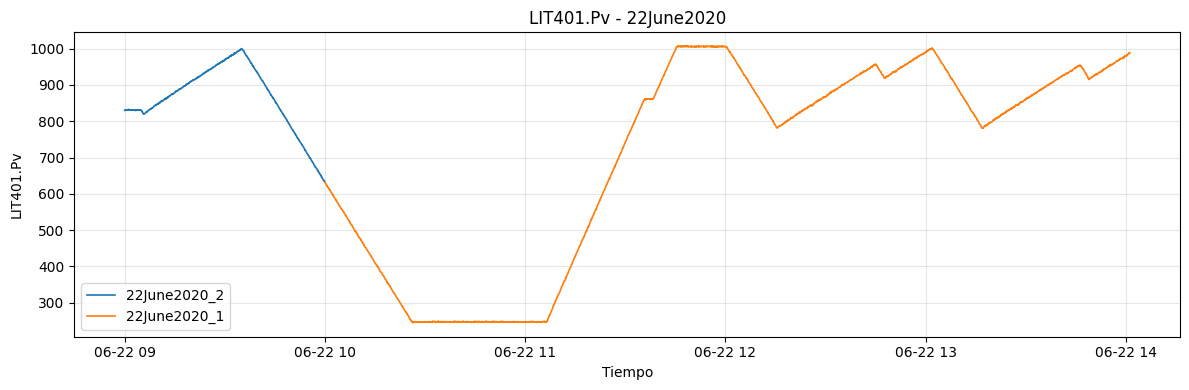

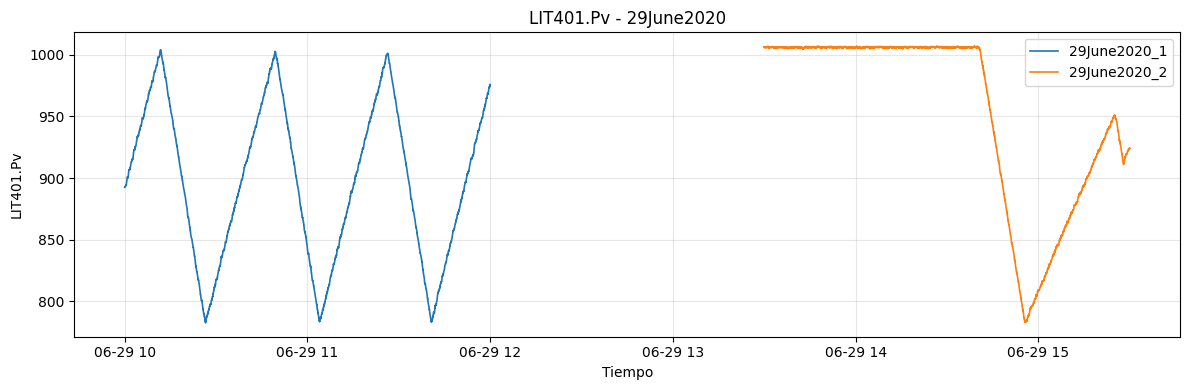

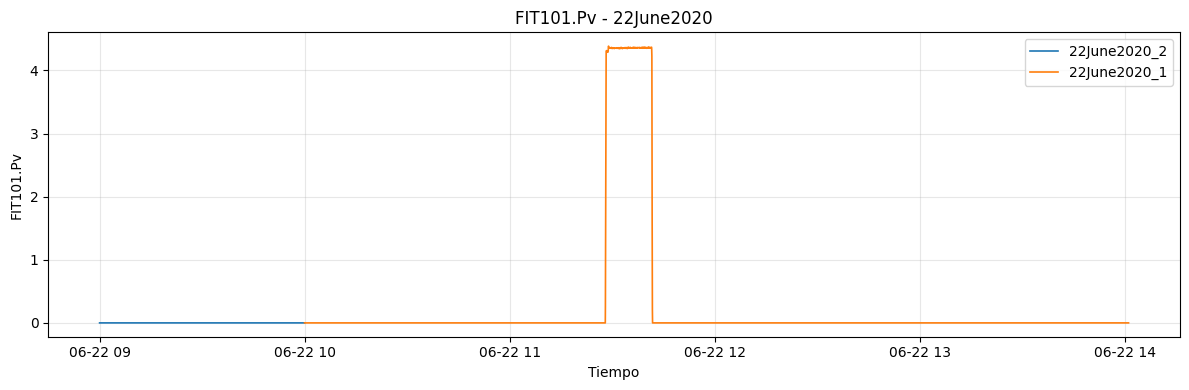

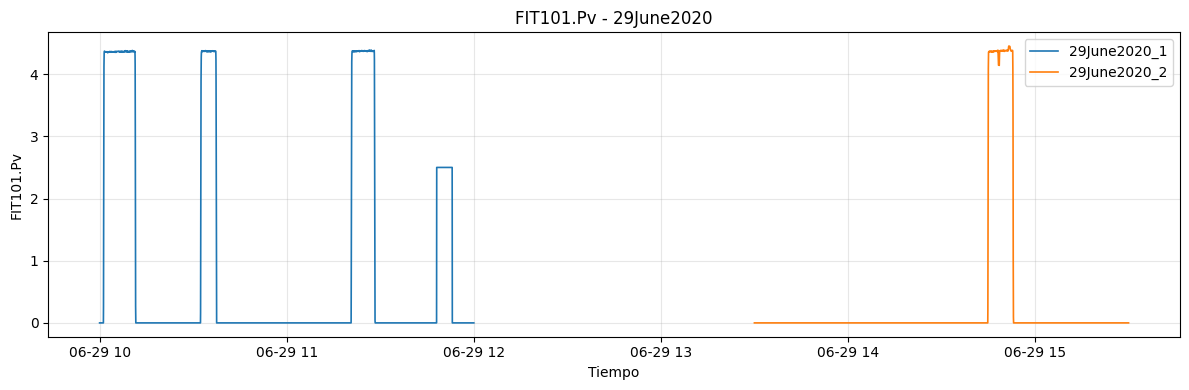

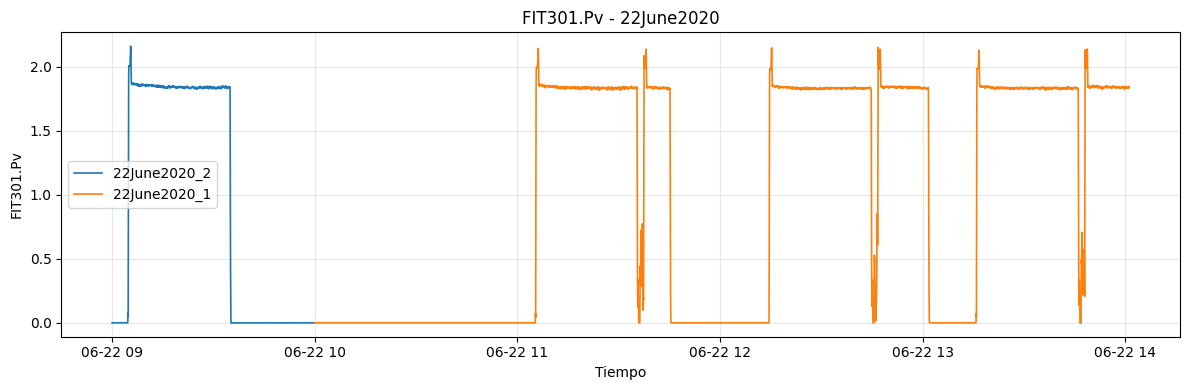

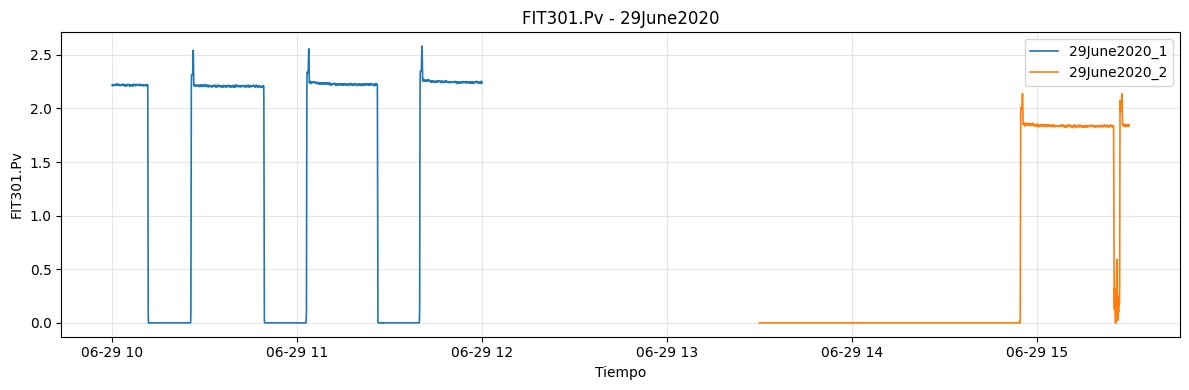

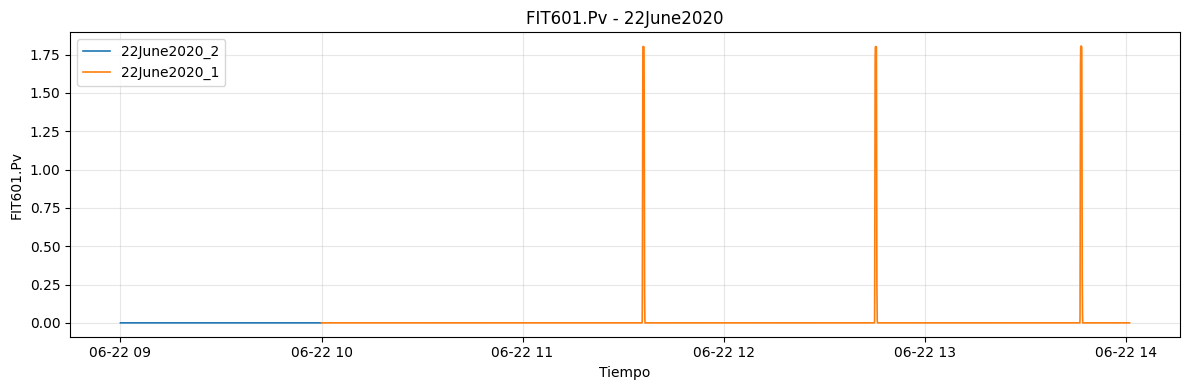

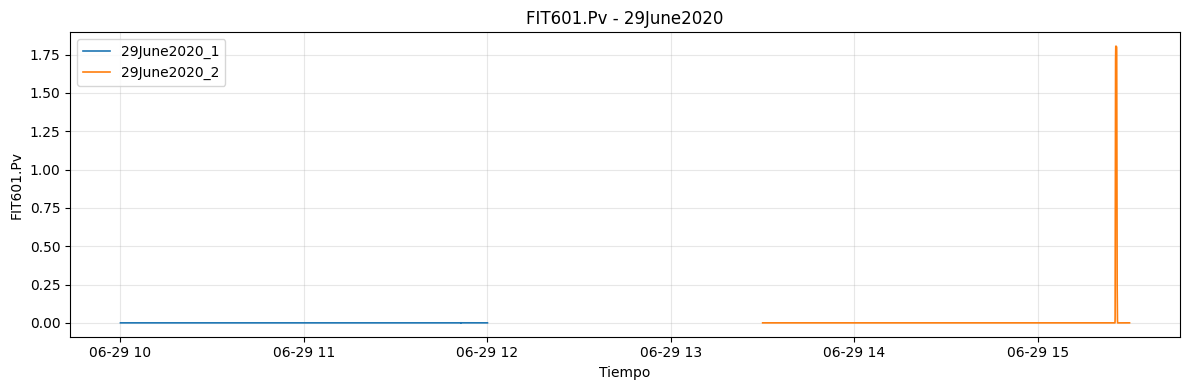

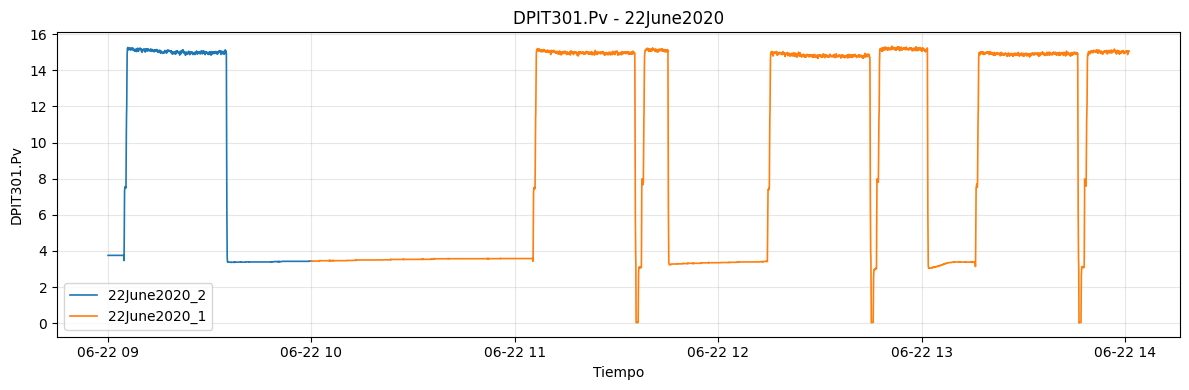

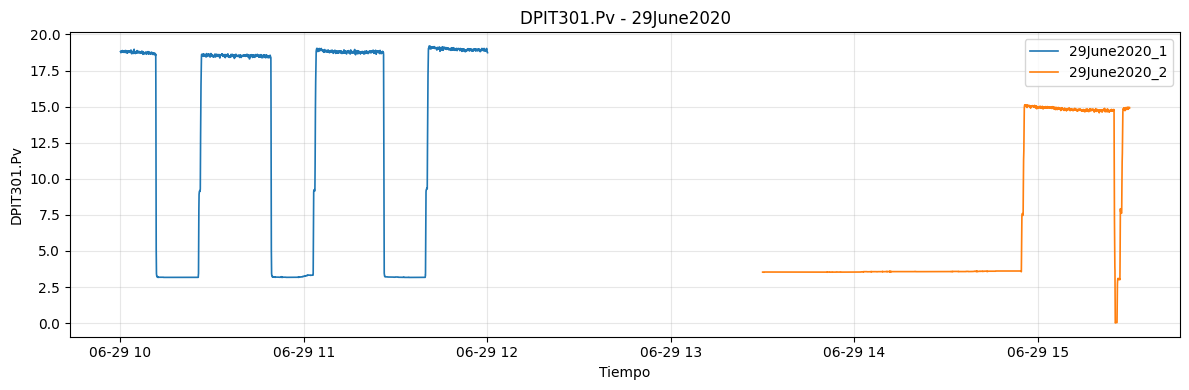

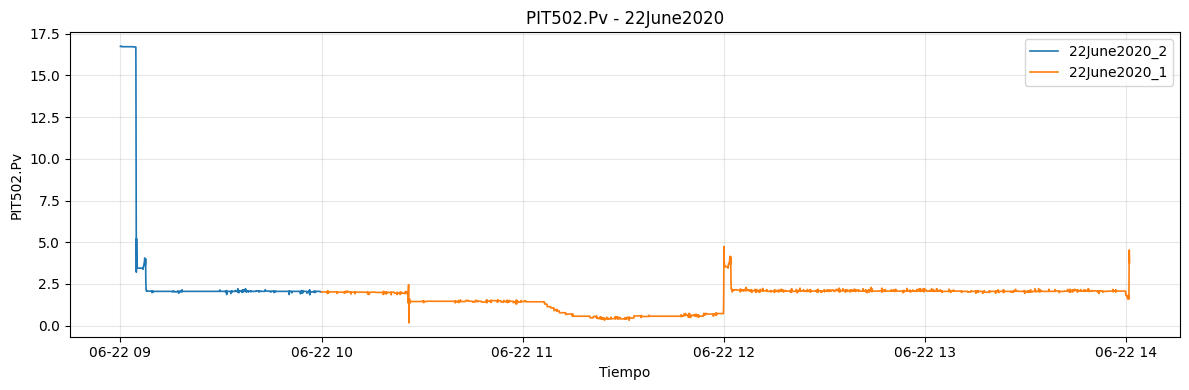

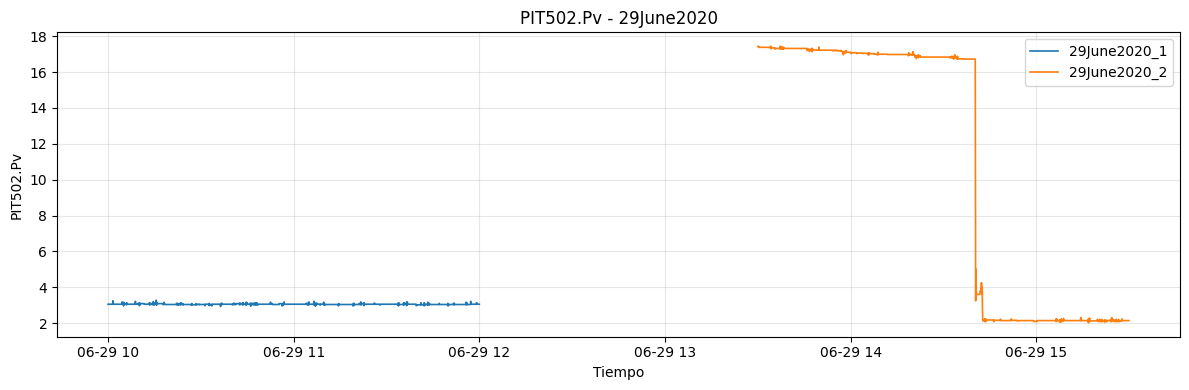

In [15]:
sensors_to_review = [
    "AIT201.Pv", "AIT202.Pv", "AIT203.Pv",
    "LIT101.Pv", "LIT301.Pv", "LIT401.Pv",
    "FIT101.Pv", "FIT301.Pv", "FIT601.Pv",
    "DPIT301.Pv", "PIT502.Pv"
]

for sensor in sensors_to_review:
    plot_sensor_time_series_by_day(files, sensor)

In [16]:
def inspect_time_gaps(files, gap_minutes=5):
    rows = []

    for name, df in files.items():
        df_sorted = df.sort_values("t_stamp").reset_index(drop=True)
        diffs = df_sorted["t_stamp"].diff().dt.total_seconds().fillna(0)

        gap_idx = diffs[diffs > gap_minutes * 60].index.tolist()

        for idx in gap_idx:
            rows.append({
                "file": name,
                "gap_index": int(idx),
                "prev_time": df_sorted.loc[idx - 1, "t_stamp"],
                "curr_time": df_sorted.loc[idx, "t_stamp"],
                "gap_minutes": round(diffs.loc[idx] / 60, 2)
            })

    return pd.DataFrame(rows)

In [17]:
gap_report = inspect_time_gaps(files, gap_minutes=5)
gap_report

""


## Documentación y clasificación de picos

In [18]:
def detect_peak_events(df, sensor_col, z_thresh=3.0):
    s = df[sensor_col].copy().reset_index(drop=True)
    diff = s.diff().abs()

    threshold = diff.mean() + z_thresh * diff.std()
    idx = diff[diff > threshold].index.tolist()

    rows = []
    for i in idx:
        rows.append({
            "sensor": sensor_col,
            "index": int(i),
            "value": float(s.iloc[i]),
            "prev_value": float(s.iloc[i-1]) if i > 0 else np.nan,
            "abs_change": float(diff.iloc[i]),
            "timestamp": df["t_stamp"].iloc[i] if "t_stamp" in df.columns else None
        })

    return pd.DataFrame(rows)

In [19]:
peak_tables = {}

for name, df in files.items():
    sensor_events = []
    for sensor in sensors_to_review:
        events = detect_peak_events(df, sensor, z_thresh=3.0)
        if not events.empty:
            events["file"] = name
            sensor_events.append(events)
    peak_tables[name] = pd.concat(sensor_events, ignore_index=True) if sensor_events else pd.DataFrame()

peak_tables["22June2020_1"].head(20)

,sensor,index,value,prev_value,abs_change,timestamp,file
0,AIT201.Pv,368,18.264547,17.976160,0.288387,2020-06-22 10:06:09.835,22June2020_1
1,AIT201.Pv,418,18.104332,17.815945,0.288387,2020-06-22 10:07:00.085,22June2020_1
2,AIT201.Pv,698,18.264547,17.976160,0.288387,2020-06-22 10:11:41.485,22June2020_1
3,AIT201.Pv,1974,17.783901,18.072288,0.288387,2020-06-22 10:33:03.865,22June2020_1
4,AIT201.Pv,2045,17.783901,18.136375,0.352474,2020-06-22 10:34:15.220,22June2020_1
5,AIT201.Pv,2047,18.136375,17.783901,0.352474,2020-06-22 10:34:17.230,22June2020_1
6,AIT201.Pv,4490,17.303255,18.072288,0.769033,2020-06-22 11:15:12.445,22June2020_1
7,AIT201.Pv,4491,16.950783,17.303255,0.352472,2020-06-22 11:15:13.450,22June2020_1
8,AIT201.Pv,4492,16.502178,16.950783,0.448605,2020-06-22 11:15:14.455,22June2020_1
9,AIT201.Pv,4496,16.085619,16.662394,0.576775,2020-06-22 11:15:18.475,22June2020_1


## Visualización por índice de muestra

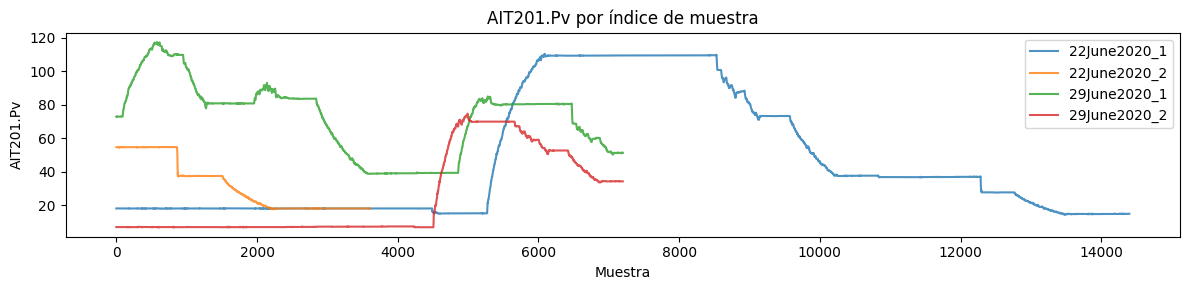

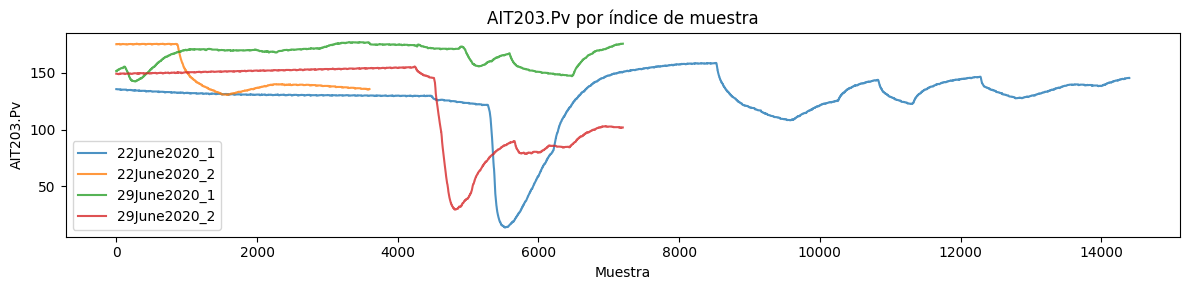

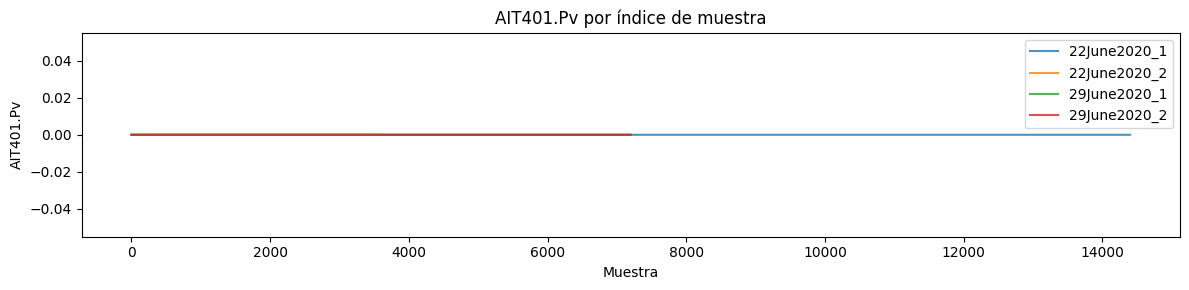

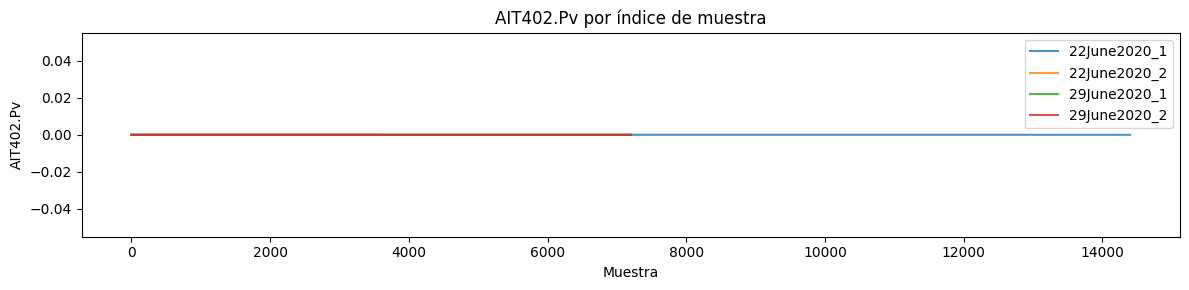

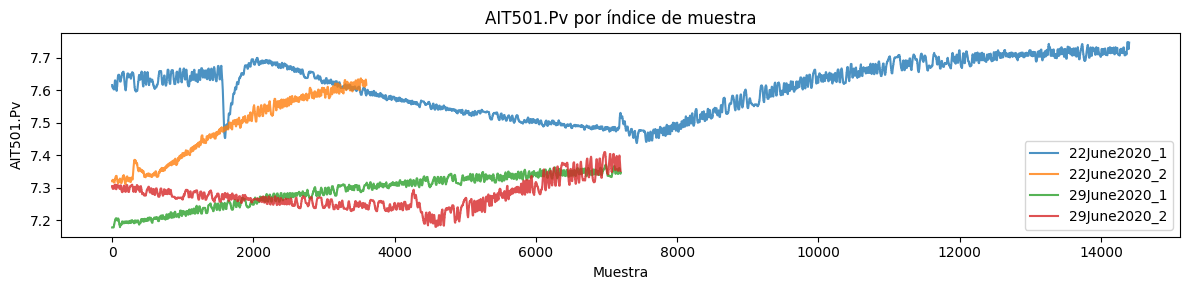

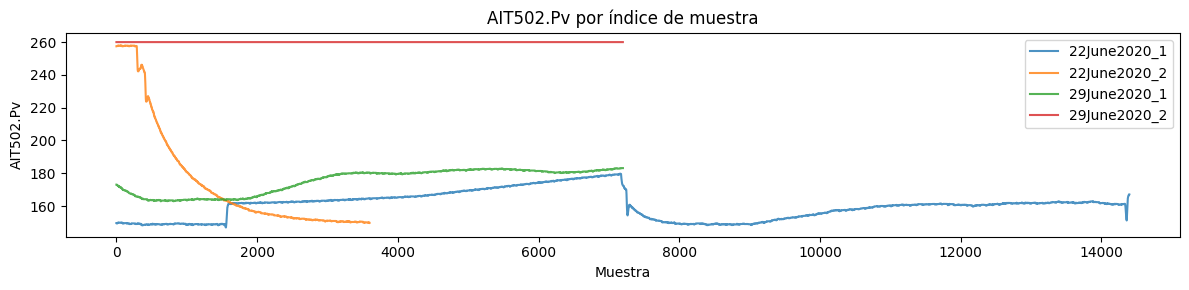

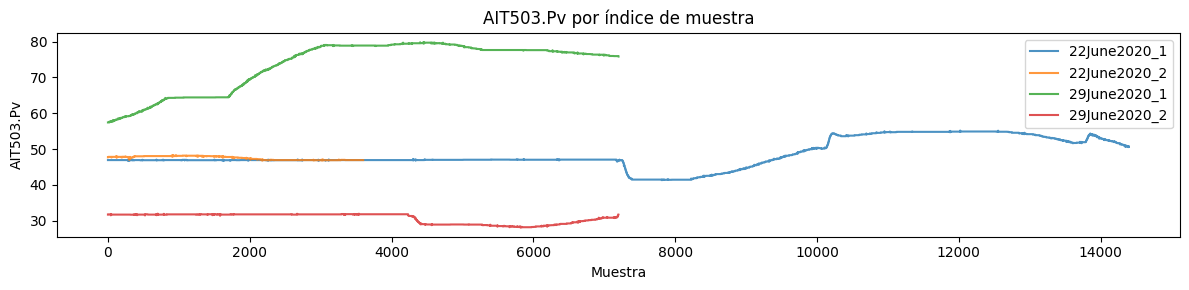

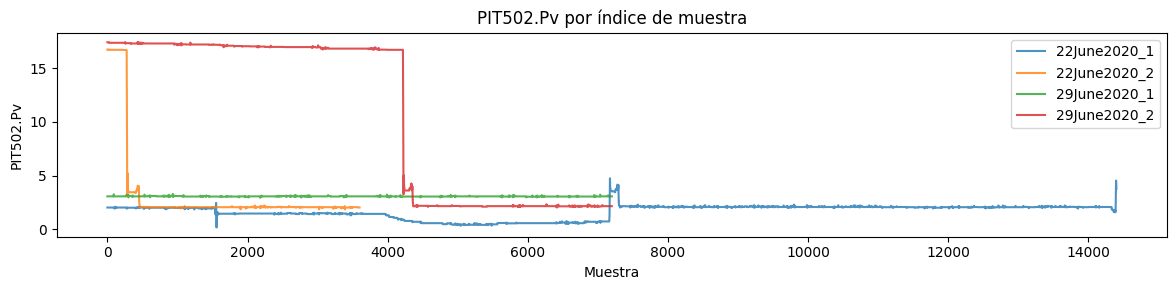

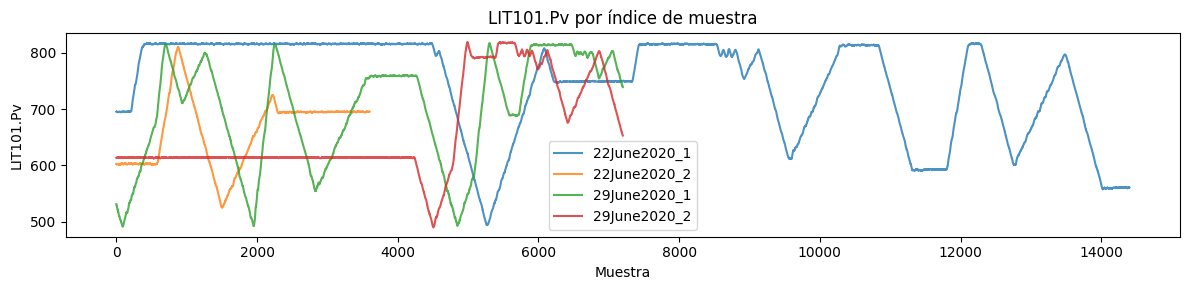

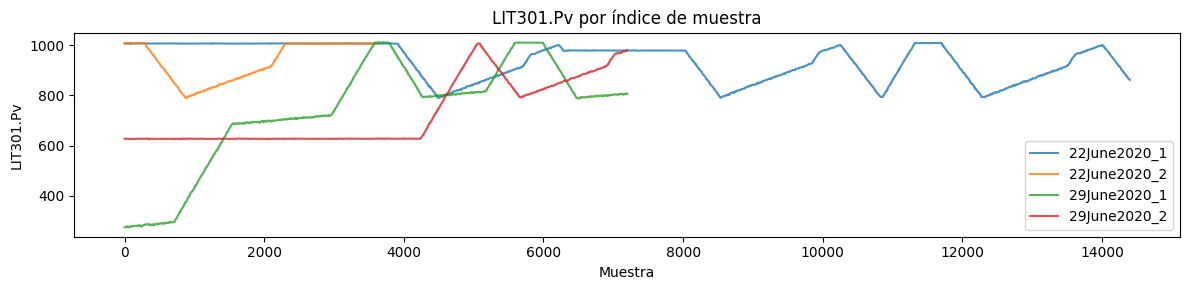

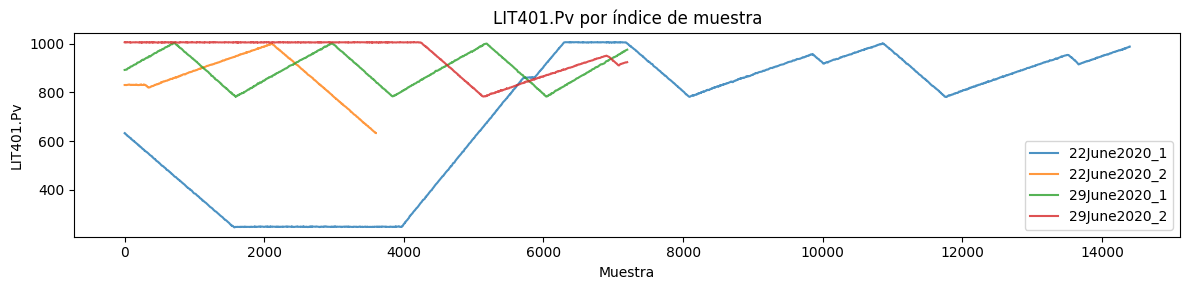

In [20]:
key_pv = [
    "AIT201.Pv", "AIT203.Pv", "AIT401.Pv", "AIT402.Pv",
    "AIT501.Pv", "AIT502.Pv", "AIT503.Pv",
    "PIT502.Pv", "LIT101.Pv", "LIT301.Pv", "LIT401.Pv"
]

for col in key_pv:
    plt.figure(figsize=(12, 3))
    for name, df in files.items():
        if col in df.columns:
            x = np.arange(len(df))
            plt.plot(x, df[col], label=name, alpha=0.8)
    plt.title(f"{col} por índice de muestra")
    plt.xlabel("Muestra")
    plt.ylabel(col)
    plt.legend()
    plt.tight_layout()
    plt.show()

## Variabilidad inicial vs resto

In [21]:
def compare_initial_variability(df, cols, first_n=600):
    rows = []
    for col in cols:
        s = df[col].dropna()
        if len(s) > first_n + 10:
            init_std = s.iloc[:first_n].std()
            rest_std = s.iloc[first_n:].std()
            ratio = np.nan if rest_std == 0 else init_std / rest_std
            rows.append({
                "feature": col,
                "init_std": init_std,
                "rest_std": rest_std,
                "ratio_init_rest": ratio
            })
    return pd.DataFrame(rows).sort_values("ratio_init_rest", ascending=False)

for name, df in files.items():
    print(f"\n===== {name} =====")
    display(compare_initial_variability(df, key_pv, first_n=600).head(15))


===== 22June2020_1 =====


,feature,init_std,rest_std,ratio_init_rest
8,LIT101.Pv,54.382700,86.081914,0.631755
4,AIT501.Pv,0.017662,0.081865,0.215742
10,LIT401.Pv,42.867835,284.353783,0.150755
5,AIT502.Pv,0.420308,8.177227,0.051400
7,PIT502.Pv,0.024143,0.639629,0.037745
1,AIT203.Pv,0.653455,25.529389,0.025596
6,AIT503.Pv,0.032274,3.980477,0.008108
9,LIT301.Pv,0.106097,70.637370,0.001502
0,AIT201.Pv,0.045991,36.273969,0.001268
2,AIT401.Pv,0.000000,0.000000,NaN



===== 22June2020_2 =====


,feature,init_std,rest_std,ratio_init_rest
7,PIT502.Pv,6.907238,0.025670,269.077200
5,AIT502.Pv,17.289042,14.508876,1.191618
9,LIT301.Pv,38.750382,79.589927,0.486875
6,AIT503.Pv,0.166775,0.524015,0.318264
4,AIT501.Pv,0.017443,0.083189,0.209682
10,LIT401.Pv,6.207589,97.447999,0.063702
8,LIT101.Pv,0.991404,59.540454,0.016651
1,AIT203.Pv,0.155849,12.020862,0.012965
0,AIT201.Pv,0.055559,11.663155,0.004764
2,AIT401.Pv,0.000000,0.000000,NaN



===== 29June2020_1 =====


,feature,init_std,rest_std,ratio_init_rest
7,PIT502.Pv,0.024872,0.026659,0.932936
0,AIT201.Pv,15.003837,20.832394,0.720217
8,LIT101.Pv,61.620932,89.110475,0.691512
1,AIT203.Pv,4.888346,8.034780,0.608398
10,LIT401.Pv,27.776044,63.430190,0.437899
5,AIT502.Pv,2.954698,7.216069,0.409461
6,AIT503.Pv,1.204388,5.560633,0.216592
4,AIT501.Pv,0.006860,0.042808,0.160259
9,LIT301.Pv,4.909440,166.221279,0.029536
2,AIT401.Pv,0.000000,0.000000,NaN



===== 29June2020_2 =====


,feature,init_std,rest_std,ratio_init_rest
4,AIT501.Pv,0.008821,0.043598,0.202331
6,AIT503.Pv,0.046731,1.400204,0.033374
1,AIT203.Pv,0.253332,37.776515,0.006706
7,PIT502.Pv,0.036449,7.366360,0.004948
9,LIT301.Pv,0.583679,130.136894,0.004485
10,LIT401.Pv,0.300313,72.050580,0.004168
8,LIT101.Pv,0.337277,84.049880,0.004013
0,AIT201.Pv,0.044301,24.994582,0.001772
2,AIT401.Pv,0.000000,0.000000,NaN
3,AIT402.Pv,0.000000,0.000000,NaN


## Perfilamiento por columna

In [22]:
profile_rows = []

for col in feature_cols:
    col_type = (
        "continuous" if col in pv_cols
        else "discrete" if col in status_cols + state_cols
        else "other"
    )
    
    values = pd.concat([df[col] for df in files.values()], axis=0)
    
    profile_rows.append({
        "feature": col,
        "type": col_type,
        "n_unique": values.nunique(dropna=True),
        "missing": values.isna().sum(),
        "is_constant": values.nunique(dropna=True) <= 1,
        "min": values.min() if col_type == "continuous" else None,
        "max": values.max() if col_type == "continuous" else None,
        "mean": values.mean() if col_type == "continuous" else None,
        "std": values.std() if col_type == "continuous" else None
    })

profile_df = pd.DataFrame(profile_rows).sort_values(["type", "feature"])
profile_df

,feature,type,n_unique,missing,is_constant,min,max,mean,std
0,AIT201.Pv,continuous,1817,0,False,6.729044,117.405792,4.538645e+01,3.333202e+01
1,AIT202.Pv,continuous,5838,0,False,6.525122,9.695784,8.194726e+00,8.985818e-01
2,AIT203.Pv,continuous,2954,0,False,13.919508,177.108429,1.379827e+02,2.993334e+01
3,AIT401.Pv,continuous,1,0,True,0.000000,0.000000,0.000000e+00,0.000000e+00
4,AIT402.Pv,continuous,1,0,True,0.000000,0.000000,0.000000e+00,0.000000e+00
5,AIT501.Pv,continuous,1369,0,False,7.177519,7.747885,7.449547e+00,1.689963e-01
6,AIT502.Pv,continuous,1282,0,False,146.936676,260.000000,1.876159e+02,4.132093e+01
7,AIT503.Pv,continuous,613,0,False,28.101768,79.851320,4.998782e+01,1.498397e+01
8,AIT504.Pv,continuous,358,0,False,0.038452,101.473984,2.353729e+00,4.103129e+00
9,DPIT301.Pv,continuous,1125,0,False,0.016006,19.191370,9.576453e+00,6.394101e+00


In [23]:
for name, df in files.items():
    print(f"\n===== {name} =====")
    print("NaN totales:", df.isna().sum().sum())


===== 22June2020_1 =====
NaN totales: 0

===== 22June2020_2 =====
NaN totales: 0

===== 29June2020_1 =====
NaN totales: 0

===== 29June2020_2 =====
NaN totales: 0


## Columnas constantes

Se identifican y eliminan las columnas constantes.

In [24]:
constant_cols = profile_df.loc[profile_df["is_constant"], "feature"].tolist()
print("Columnas constantes:", constant_cols)

Columnas constantes: ['AIT401.Pv', 'AIT402.Pv', 'P102.Status', 'P202.Status', 'P204.Status', 'P206.Status', 'P302.Status', 'P402.Status', 'P403.Status', 'P404.Status', 'P502.Status']


In [25]:
for name in files:
    files[name] = files[name].drop(columns=constant_cols)

pv_cols = [c for c in pv_cols if c not in constant_cols]
status_cols = [c for c in status_cols if c not in constant_cols]
state_cols = [c for c in state_cols if c not in constant_cols]

feature_cols = pv_cols + status_cols + state_cols
continuous_cols = pv_cols
discrete_cols = status_cols + state_cols

print("Features después de eliminar constantes:", len(feature_cols))
print("Continuas:", len(continuous_cols))
print("Discretas:", len(discrete_cols))

Features después de eliminar constantes: 49
Continuas: 23
Discretas: 26


## Recorte de warm-up

In [26]:
WARMUP = 120  # 120 segundos = 2 minutos

files = {
    name: df.iloc[WARMUP:].reset_index(drop=True)
    for name, df in files.items()
}

for name, df in files.items():
    print(name, df.shape)

22June2020_1 (14280, 50)
22June2020_2 (3480, 50)
29June2020_1 (7081, 50)
29June2020_2 (7080, 50)


In [27]:
for name, df in files.items():
    missing = df[feature_cols].isna().sum().sum()
    print(name, "missing total:", missing)

22June2020_1 missing total: 0
22June2020_2 missing total: 0
29June2020_1 missing total: 0
29June2020_2 missing total: 0


## Partición temporal sin cruces entre archivos o segmentos

A partir de este punto se conservará la estructura por archivo al construir ventanas,
de modo que ninguna ventana mezcle muestras de archivos distintos o segmentos no consecutivos.

Se tomó la decisión de particionar cada archivo, crear las ventanas en cada archivo para evitar gaps temporalees y luego concatenar las ventanas.

In [28]:
def temporal_split(df, train_ratio=0.6, val_ratio=0.2):
    n = len(df)

    train_end = int(n * train_ratio)
    val_end = int(n * (train_ratio + val_ratio))

    train_df = df.iloc[:train_end].copy()
    val_df   = df.iloc[train_end:val_end].copy()
    test_df  = df.iloc[val_end:].copy()

    return train_df, val_df, test_df

In [29]:
split_by_file = {}

for name, df_i in files.items():
    # conservar timestamp + features
    df_base = df_i[["t_stamp"] + feature_cols].copy()

    train_i, val_i, test_i = temporal_split(df_base, train_ratio=0.6, val_ratio=0.2)

    split_by_file[name] = {
        "train": train_i,
        "val": val_i,
        "test": test_i
    }

    print(f"{name}:")
    print("  train:", train_i.shape)
    print("  val:  ", val_i.shape)
    print("  test: ", test_i.shape)

22June2020_1:
  train: (8568, 50)
  val:   (2856, 50)
  test:  (2856, 50)
22June2020_2:
  train: (2088, 50)
  val:   (696, 50)
  test:  (696, 50)
29June2020_1:
  train: (4248, 50)
  val:   (1416, 50)
  test:  (1417, 50)
29June2020_2:
  train: (4248, 50)
  val:   (1416, 50)
  test:  (1416, 50)


In [30]:
train_df = pd.concat(
    [split_by_file[name]["train"][feature_cols] for name in split_by_file],
    axis=0
).reset_index(drop=True)

val_df = pd.concat(
    [split_by_file[name]["val"][feature_cols] for name in split_by_file],
    axis=0
).reset_index(drop=True)

test_df = pd.concat(
    [split_by_file[name]["test"][feature_cols] for name in split_by_file],
    axis=0
).reset_index(drop=True)

print("Train:", train_df.shape)
print("Val:  ", val_df.shape)
print("Test: ", test_df.shape)

Train: (19152, 49)
Val:   (6384, 49)
Test:  (6385, 49)


## Escalado de variables

In [31]:
from sklearn.preprocessing import StandardScaler

scaler_cont = StandardScaler()

train_all_cont = pd.concat(
    [split_by_file[name]["train"][continuous_cols] for name in split_by_file],
    axis=0
)

scaler_cont.fit(train_all_cont)

,copy,True
,with_mean,True
,with_std,True


In [32]:
from sklearn.preprocessing import StandardScaler

scaler_cont = StandardScaler()

train_all_cont = pd.concat(
    [split_by_file[name]["train"][continuous_cols] for name in split_by_file],
    axis=0
)

scaler_cont.fit(train_all_cont)

,copy,True
,with_mean,True
,with_std,True


In [33]:
def scale_split_part(df_part, scaler_cont, continuous_cols, discrete_cols):
    cont = pd.DataFrame(
        scaler_cont.transform(df_part[continuous_cols]),
        columns=continuous_cols,
        index=df_part.index
    )

    # Las discretas se conservan crudas por ahora;
    # luego se resumirán por ventana.
    disc = df_part[discrete_cols].copy()

    return cont, disc

In [34]:
scaled_split_by_file = {}

for name in split_by_file:
    scaled_split_by_file[name] = {}

    for subset in ["train", "val", "test"]:
        cont_part, disc_part = scale_split_part(
            split_by_file[name][subset],
            scaler_cont=scaler_cont,
            continuous_cols=continuous_cols,
            discrete_cols=discrete_cols
        )

        scaled_split_by_file[name][subset] = {
            "cont": cont_part,
            "disc": disc_part
        }

In [35]:
# Verificación rápida
for name in scaled_split_by_file:
    print(f"\n{name}")
    for subset in ["train", "val", "test"]:
        print(
            subset,
            "cont:", scaled_split_by_file[name][subset]["cont"].shape,
            "disc:", scaled_split_by_file[name][subset]["disc"].shape
        )


22June2020_1
train cont: (8568, 23) disc: (8568, 26)
val cont: (2856, 23) disc: (2856, 26)
test cont: (2856, 23) disc: (2856, 26)

22June2020_2
train cont: (2088, 23) disc: (2088, 26)
val cont: (696, 23) disc: (696, 26)
test cont: (696, 23) disc: (696, 26)

29June2020_1
train cont: (4248, 23) disc: (4248, 26)
val cont: (1416, 23) disc: (1416, 26)
test cont: (1417, 23) disc: (1417, 26)

29June2020_2
train cont: (4248, 23) disc: (4248, 26)
val cont: (1416, 23) disc: (1416, 26)
test cont: (1416, 23) disc: (1416, 26)


## Correlación de sensores continuos

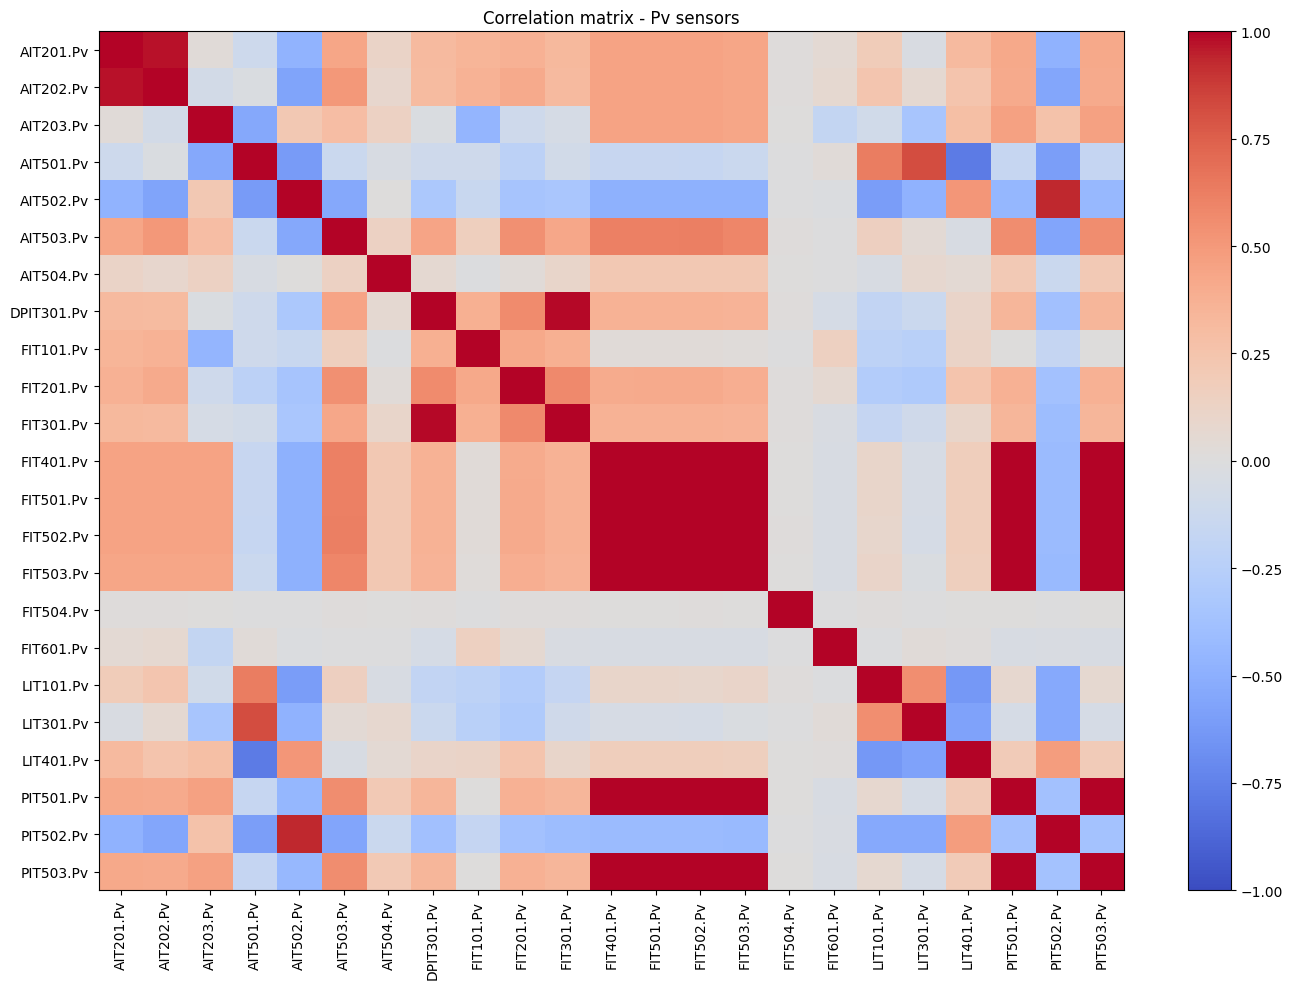

In [36]:
corr = train_df[continuous_cols].corr()

plt.figure(figsize=(14, 10))
plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1, aspect="auto")
plt.colorbar()
plt.xticks(range(len(continuous_cols)), continuous_cols, rotation=90)
plt.yticks(range(len(continuous_cols)), continuous_cols)
plt.title("Correlation matrix - Pv sensors")
plt.tight_layout()
plt.show()

## Crear ventanas temporales

In [37]:
def create_windows(data, window_size=60, stride=5):
    windows = []
    for i in range(0, len(data) - window_size + 1, stride):
        windows.append(data[i:i+window_size])
    return np.array(windows)

In [38]:
def build_windows_with_origin(scaled_split_by_file, subset, window_size=60, stride=5):
    cont_windows = []
    disc_windows = []
    origin_tracker = []

    for name in scaled_split_by_file:
        cont_df = scaled_split_by_file[name][subset]["cont"]
        disc_df = scaled_split_by_file[name][subset]["disc"]

        if len(cont_df) < window_size:
            continue

        cont_arr = cont_df.values
        disc_arr = disc_df.values

        n_windows = 0
        for i in range(0, len(cont_df) - window_size + 1, stride):
            cont_windows.append(cont_arr[i:i+window_size])
            disc_windows.append(disc_arr[i:i+window_size])
            origin_tracker.append(name)
            n_windows += 1

    if len(cont_windows) == 0:
        return np.empty((0, window_size, len(continuous_cols))), np.empty((0, window_size, len(discrete_cols))), []

    return np.array(cont_windows), np.array(disc_windows), origin_tracker

In [39]:
# Mejores hiperparámetros encontrados con Optuna
BEST_PARAMS = {
    "window_size": 60,
    "stride": 1,
    "n_conv_layers": 1,
    "conv_channels_1": 64,
    "conv_channels_2": 16,
    "conv_channels_3": 8,
    "kernel_size": 5,
    "disc_hidden_1": 64,
    "disc_hidden_2": 16,
    "fusion_hidden": 256,
    "dropout": 0.01837443752413843,
    "batch_size": 128,
    "lr": 0.00023729585064585673,
    "optimizer": "Adam",
    "epochs": 30
}

L = BEST_PARAMS["window_size"]
stride = BEST_PARAMS["stride"]

train_cont_windows, train_disc_windows, train_origin = build_windows_with_origin(
    scaled_split_by_file, subset="train", window_size=L, stride=stride
)

val_cont_windows, val_disc_windows, val_origin = build_windows_with_origin(
    scaled_split_by_file, subset="val", window_size=L, stride=stride
)

test_cont_windows, test_disc_windows, test_origin = build_windows_with_origin(
    scaled_split_by_file, subset="test", window_size=L, stride=stride
)

print("Train cont windows:", train_cont_windows.shape)
print("Train disc windows:", train_disc_windows.shape)

print("Val cont windows:", val_cont_windows.shape)
print("Val disc windows:", val_disc_windows.shape)

print("Test cont windows:", test_cont_windows.shape)
print("Test disc windows:", test_disc_windows.shape)

Train cont windows: (18916, 60, 23)
Train disc windows: (18916, 60, 26)
Val cont windows: (6148, 60, 23)
Val disc windows: (6148, 60, 26)
Test cont windows: (6149, 60, 23)
Test disc windows: (6149, 60, 26)


In [40]:
from collections import Counter

print("Train distribution:", Counter(train_origin))
print("Val distribution:", Counter(val_origin))
print("Test distribution:", Counter(test_origin))

Train distribution: Counter({'22June2020_1': 8509, '29June2020_1': 4189, '29June2020_2': 4189, '22June2020_2': 2029})
Val distribution: Counter({'22June2020_1': 2797, '29June2020_1': 1357, '29June2020_2': 1357, '22June2020_2': 637})
Test distribution: Counter({'22June2020_1': 2797, '29June2020_1': 1358, '29June2020_2': 1357, '22June2020_2': 637})


In [41]:
def check_window_boundaries(origin_list):
    changes = 0
    for i in range(1, len(origin_list)):
        if origin_list[i] != origin_list[i-1]:
            changes += 1
    return changes

print("Cambios de archivo en train:", check_window_boundaries(train_origin))

Cambios de archivo en train: 3


## Resumen de variables discretas por ventana

Las variables discretas no se ingresan como secuencia continua al autoencoder.
En su lugar, se resumen por ventana para capturar el estado dominante del sistema
y la dinámica básica de cambios de estado.

In [42]:
def summarize_discrete_windows(disc_windows, discrete_cols):
    summary_rows = []

    for w in disc_windows:
        feats = {}

        for j, col in enumerate(discrete_cols):
            values = w[:, j]

            mode_val = pd.Series(values).mode().iloc[0]
            transitions = np.sum(values[1:] != values[:-1])
            nunique = len(np.unique(values))
            dominance = pd.Series(values).value_counts(normalize=True).iloc[0]

            feats[f"{col}__mode"] = mode_val
            feats[f"{col}__transitions"] = transitions
            feats[f"{col}__nunique"] = nunique
            feats[f"{col}__dominance"] = dominance

        summary_rows.append(feats)

    return pd.DataFrame(summary_rows)

In [43]:
train_disc_summary = summarize_discrete_windows(train_disc_windows, discrete_cols)
val_disc_summary   = summarize_discrete_windows(val_disc_windows, discrete_cols)
test_disc_summary  = summarize_discrete_windows(test_disc_windows, discrete_cols)

print("Train disc summary:", train_disc_summary.shape)
print("Val disc summary:", val_disc_summary.shape)
print("Test disc summary:", test_disc_summary.shape)

Train disc summary: (18916, 104)
Val disc summary: (6148, 104)
Test disc summary: (6149, 104)


In [44]:
train_disc_summary.head()

,MV101.Status__mode,MV101.Status__transitions,MV101.Status__nunique,MV101.Status__dominance,MV201.Status__mode,MV201.Status__transitions,MV201.Status__nunique,MV201.Status__dominance,MV301.Status__mode,MV301.Status__transitions,...,P4_STATE__nunique,P4_STATE__dominance,P5_STATE__mode,P5_STATE__transitions,P5_STATE__nunique,P5_STATE__dominance,P6_STATE__mode,P6_STATE__transitions,P6_STATE__nunique,P6_STATE__dominance
0,1.0,0,1,1.0,1.0,0,1,1.0,1.0,0,...,1,1.0,12.0,0,1,1.0,2.0,0,1,1.0
1,1.0,0,1,1.0,1.0,0,1,1.0,1.0,0,...,1,1.0,12.0,0,1,1.0,2.0,0,1,1.0
2,1.0,0,1,1.0,1.0,0,1,1.0,1.0,0,...,1,1.0,12.0,0,1,1.0,2.0,0,1,1.0
3,1.0,0,1,1.0,1.0,0,1,1.0,1.0,0,...,1,1.0,12.0,0,1,1.0,2.0,0,1,1.0
4,1.0,0,1,1.0,1.0,0,1,1.0,1.0,0,...,1,1.0,12.0,0,1,1.0,2.0,0,1,1.0


## Reorganizar para Conv1D

In [45]:
# Secuencia principal para Conv1D: solo continuas
X_train = np.transpose(train_cont_windows, (0, 2, 1))
X_val   = np.transpose(val_cont_windows, (0, 2, 1))
X_test  = np.transpose(test_cont_windows, (0, 2, 1))

# Features discretas agregadas por ventana
X_train_disc = train_disc_summary.values
X_val_disc   = val_disc_summary.values
X_test_disc  = test_disc_summary.values

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

print("X_train_disc:", X_train_disc.shape)
print("X_val_disc:", X_val_disc.shape)
print("X_test_disc:", X_test_disc.shape)

X_train: (18916, 23, 60)
X_val: (6148, 23, 60)
X_test: (6149, 23, 60)
X_train_disc: (18916, 104)
X_val_disc: (6148, 104)
X_test_disc: (6149, 104)


## Tensores y DataLoaders

In [46]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [47]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_val_tensor   = torch.tensor(X_val, dtype=torch.float32)
X_test_tensor  = torch.tensor(X_test, dtype=torch.float32)

X_train_disc_tensor = torch.tensor(X_train_disc, dtype=torch.float32)
X_val_disc_tensor   = torch.tensor(X_val_disc, dtype=torch.float32)
X_test_disc_tensor  = torch.tensor(X_test_disc, dtype=torch.float32)

In [48]:
y_train_tensor = X_train_tensor.clone()
y_val_tensor   = X_val_tensor.clone()
y_test_tensor  = X_test_tensor.clone()

In [49]:
train_dataset = TensorDataset(X_train_tensor, X_train_disc_tensor, y_train_tensor)
val_dataset   = TensorDataset(X_val_tensor, X_val_disc_tensor, y_val_tensor)
test_dataset  = TensorDataset(X_test_tensor, X_test_disc_tensor, y_test_tensor)

In [50]:
BATCH_SIZE = BEST_PARAMS["batch_size"]

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

## Modelo Conv1D AC + MLP

In [51]:
class HybridConv1DAutoencoder(nn.Module):
    def __init__(
        self,
        cont_channels,
        seq_len,
        disc_dim,
        n_conv_layers=2,
        conv_channels_1=32,
        conv_channels_2=16,
        conv_channels_3=8,
        kernel_size=3,
        disc_hidden_1=64,
        disc_hidden_2=32,
        fusion_hidden=128,
        dropout=0.1
    ):
        super().__init__()

        self.cont_channels = cont_channels
        self.seq_len = seq_len
        self.disc_dim = disc_dim
        self.n_conv_layers = n_conv_layers

        # -------------------------
        # Encoder conv dinámico
        # -------------------------
        channels_list = [cont_channels]

        if n_conv_layers >= 1:
            channels_list.append(conv_channels_1)
        if n_conv_layers >= 2:
            channels_list.append(conv_channels_2)
        if n_conv_layers >= 3:
            channels_list.append(conv_channels_3)

        encoder_layers = []
        current_seq_len = seq_len

        for i in range(len(channels_list) - 1):
            encoder_layers.extend([
                nn.Conv1d(
                    in_channels=channels_list[i],
                    out_channels=channels_list[i + 1],
                    kernel_size=kernel_size,
                    padding=kernel_size // 2
                ),
                nn.ReLU(),
                nn.Dropout(dropout),
                nn.MaxPool1d(kernel_size=2)
            ])
            current_seq_len = current_seq_len // 2

        self.encoder_conv = nn.Sequential(*encoder_layers)

        self.reduced_len = current_seq_len
        self.last_conv_channels = channels_list[-1]
        self.conv_flat_dim = self.last_conv_channels * self.reduced_len

        # -------------------------
        # Rama discreta
        # -------------------------
        self.encoder_disc = nn.Sequential(
            nn.Linear(disc_dim, disc_hidden_1),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(disc_hidden_1, disc_hidden_2),
            nn.ReLU()
        )

        # -------------------------
        # Fusión
        # -------------------------
        self.fusion = nn.Sequential(
            nn.Linear(self.conv_flat_dim + disc_hidden_2, fusion_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(fusion_hidden, self.conv_flat_dim),
            nn.ReLU()
        )

        # -------------------------
        # Decoder conv dinámico
        # -------------------------
        rev_channels = channels_list[::-1]
        decoder_layers = []

        for i in range(len(rev_channels) - 1):
            decoder_layers.extend([
                nn.ConvTranspose1d(
                    in_channels=rev_channels[i],
                    out_channels=rev_channels[i + 1],
                    kernel_size=2,
                    stride=2
                ),
                nn.ReLU()
            ])

        if len(decoder_layers) > 0:
            decoder_layers = decoder_layers[:-1]

        self.decoder_conv = nn.Sequential(*decoder_layers)

    def forward(self, x_cont, x_disc):
        z_cont = self.encoder_conv(x_cont)
        z_cont_flat = z_cont.view(z_cont.size(0), -1)

        z_disc = self.encoder_disc(x_disc)

        z = torch.cat([z_cont_flat, z_disc], dim=1)
        z_fused = self.fusion(z)

        z_fused = z_fused.view(
            z_cont.size(0),
            self.last_conv_channels,
            self.reduced_len
        )

        x_hat = self.decoder_conv(z_fused)
        return x_hat

In [52]:
cont_channels = X_train.shape[1]
seq_len = X_train.shape[2]
disc_dim = X_train_disc.shape[1]

model = HybridConv1DAutoencoder(
    cont_channels=cont_channels,
    seq_len=seq_len,
    disc_dim=disc_dim,
    n_conv_layers=BEST_PARAMS["n_conv_layers"],
    conv_channels_1=BEST_PARAMS["conv_channels_1"],
    conv_channels_2=BEST_PARAMS["conv_channels_2"],
    conv_channels_3=BEST_PARAMS["conv_channels_3"],
    kernel_size=BEST_PARAMS["kernel_size"],
    disc_hidden_1=BEST_PARAMS["disc_hidden_1"],
    disc_hidden_2=BEST_PARAMS["disc_hidden_2"],
    fusion_hidden=BEST_PARAMS["fusion_hidden"],
    dropout=BEST_PARAMS["dropout"]
).to(device)

model

HybridConv1DAutoencoder(
  (encoder_conv): Sequential(
    (0): Conv1d(23, 64, kernel_size=(5,), stride=(1,), padding=(2,))
    (1): ReLU()
    (2): Dropout(p=0.01837443752413843, inplace=False)
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (encoder_disc): Sequential(
    (0): Linear(in_features=104, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.01837443752413843, inplace=False)
    (3): Linear(in_features=64, out_features=16, bias=True)
    (4): ReLU()
  )
  (fusion): Sequential(
    (0): Linear(in_features=1936, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.01837443752413843, inplace=False)
    (3): Linear(in_features=256, out_features=1920, bias=True)
    (4): ReLU()
  )
  (decoder_conv): Sequential(
    (0): ConvTranspose1d(64, 23, kernel_size=(2,), stride=(2,))
  )
)

## Función de pérdida y optimizador

In [53]:
criterion = nn.MSELoss()

if BEST_PARAMS["optimizer"] == "Adam":
    optimizer = torch.optim.Adam(model.parameters(), lr=BEST_PARAMS["lr"])
elif BEST_PARAMS["optimizer"] == "AdamW":
    optimizer = torch.optim.AdamW(model.parameters(), lr=BEST_PARAMS["lr"])
else:
    raise ValueError(f"Optimizador no soportado: {BEST_PARAMS['optimizer']}")

## Entrenamiento

In [54]:
def train_hybrid_autoencoder(model, train_loader, val_loader, criterion, optimizer, device, epochs=30):
    loss_history = []
    val_loss_history = []

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0

        for x_cont_batch, x_disc_batch, y_batch in train_loader:
            x_cont_batch = x_cont_batch.to(device)
            x_disc_batch = x_disc_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()

            y_hat = model(x_cont_batch, x_disc_batch)
            loss = criterion(y_hat, y_batch)

            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        train_loss /= len(train_loader)
        loss_history.append(train_loss)

        model.eval()
        val_loss = 0.0

        with torch.no_grad():
            for x_cont_batch, x_disc_batch, y_batch in val_loader:
                x_cont_batch = x_cont_batch.to(device)
                x_disc_batch = x_disc_batch.to(device)
                y_batch = y_batch.to(device)

                y_hat = model(x_cont_batch, x_disc_batch)
                loss = criterion(y_hat, y_batch)

                val_loss += loss.item()

        val_loss /= len(val_loader)
        val_loss_history.append(val_loss)

        print(f"Epoch [{epoch+1}/{epochs}] - Train Loss: {train_loss:.6f} - Val Loss: {val_loss:.6f}")

    return loss_history, val_loss_history

In [55]:
EPOCHS = BEST_PARAMS["epochs"]

loss_history, val_loss_history = train_hybrid_autoencoder(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    epochs=EPOCHS
)

Epoch [1/30] - Train Loss: 0.445836 - Val Loss: 0.376160
Epoch [2/30] - Train Loss: 0.130087 - Val Loss: 0.258160
Epoch [3/30] - Train Loss: 0.087916 - Val Loss: 0.219806
Epoch [4/30] - Train Loss: 0.072913 - Val Loss: 0.198364
Epoch [5/30] - Train Loss: 0.065061 - Val Loss: 0.185346
Epoch [6/30] - Train Loss: 0.060071 - Val Loss: 0.178717
Epoch [7/30] - Train Loss: 0.055855 - Val Loss: 0.167264
Epoch [8/30] - Train Loss: 0.052294 - Val Loss: 0.158978
Epoch [9/30] - Train Loss: 0.048398 - Val Loss: 0.155708
Epoch [10/30] - Train Loss: 0.044497 - Val Loss: 0.146263
Epoch [11/30] - Train Loss: 0.041897 - Val Loss: 0.140268
Epoch [12/30] - Train Loss: 0.039188 - Val Loss: 0.136021
Epoch [13/30] - Train Loss: 0.037301 - Val Loss: 0.134812
Epoch [14/30] - Train Loss: 0.035697 - Val Loss: 0.130465
Epoch [15/30] - Train Loss: 0.034276 - Val Loss: 0.129190
Epoch [16/30] - Train Loss: 0.033489 - Val Loss: 0.124168
Epoch [17/30] - Train Loss: 0.032163 - Val Loss: 0.123437
Epoch [18/30] - Train L

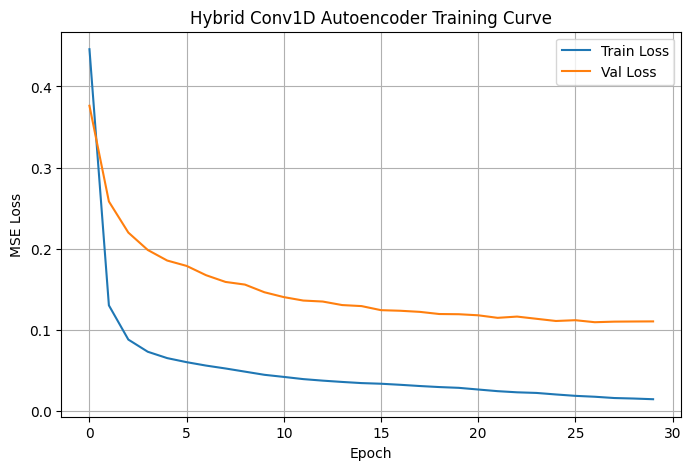

In [56]:
plt.figure(figsize=(8, 5))
plt.plot(loss_history, label="Train Loss")
plt.plot(val_loss_history, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Hybrid Conv1D Autoencoder Training Curve")
plt.grid(True)
plt.legend()
plt.show()

## Errores de reconstrucción en validación

In [57]:
def compute_reconstruction_errors(model, data_loader, device):
    model.eval()
    errors = []

    with torch.no_grad():
        for x_cont_batch, x_disc_batch, y_batch in data_loader:
            x_cont_batch = x_cont_batch.to(device)
            x_disc_batch = x_disc_batch.to(device)
            y_batch = y_batch.to(device)

            y_hat = model(x_cont_batch, x_disc_batch)

            batch_error = torch.mean((y_hat - y_batch) ** 2, dim=(1, 2))
            errors.extend(batch_error.cpu().numpy())

    return np.array(errors)

In [58]:
val_reconstruction_errors = compute_reconstruction_errors(model, val_loader, device)
test_reconstruction_errors = compute_reconstruction_errors(model, test_loader, device)

print("Validation errors shape:", val_reconstruction_errors.shape)
print("Validation error mean:", val_reconstruction_errors.mean())
print("Validation error std:", val_reconstruction_errors.std())

print("\nTest errors shape:", test_reconstruction_errors.shape)
print("Test error mean:", test_reconstruction_errors.mean())
print("Test error std:", test_reconstruction_errors.std())

Validation errors shape: (6148,)
Validation error mean: 0.1067162
Validation error std: 0.15676059

Test errors shape: (6149,)
Test error mean: 0.09934408
Test error std: 0.16197494


## Histograma de errores

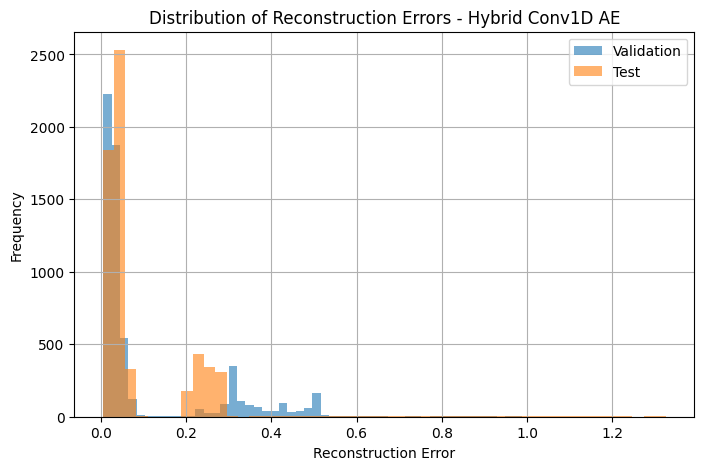

In [59]:
plt.figure(figsize=(8, 5))
plt.hist(val_reconstruction_errors, bins=50, alpha=0.6, label="Validation")
plt.hist(test_reconstruction_errors, bins=50, alpha=0.6, label="Test")
plt.xlabel("Reconstruction Error")
plt.ylabel("Frequency")
plt.title("Distribution of Reconstruction Errors - Hybrid Conv1D AE")
plt.legend()
plt.grid(True)
plt.show()

## Umbrales

In [60]:
percentiles = [90, 95, 97.5, 99, 99.5]

tau_dict = {
    p: np.percentile(val_reconstruction_errors, p)
    for p in percentiles
}

tau_df = pd.DataFrame({
    "percentile": list(tau_dict.keys()),
    "tau": list(tau_dict.values())
})

tau_df

,percentile,tau
0,90.0,0.354911
1,95.0,0.469500
2,97.5,0.510280
3,99.0,0.516329
4,99.5,0.689348


## FAR en validación y test

In [61]:
far_rows = []

for p, tau in tau_dict.items():
    far_val = np.mean(val_reconstruction_errors > tau)
    far_test = np.mean(test_reconstruction_errors > tau)

    far_rows.append({
        "percentile": p,
        "tau": tau,
        "FAR_val": far_val,
        "FAR_test": far_test,
        "FAR_val_pct": round(far_val * 100, 2),
        "FAR_test_pct": round(far_test * 100, 2)
    })

far_df = pd.DataFrame(far_rows)
far_df

,percentile,tau,FAR_val,FAR_test,FAR_val_pct,FAR_test_pct
0,90.0,0.354911,0.100033,0.027647,10.00,2.76
1,95.0,0.469500,0.050098,0.025370,5.01,2.54
2,97.5,0.510280,0.025049,0.024557,2.50,2.46
3,99.0,0.516329,0.010085,0.024557,1.01,2.46
4,99.5,0.689348,0.005042,0.019515,0.50,1.95


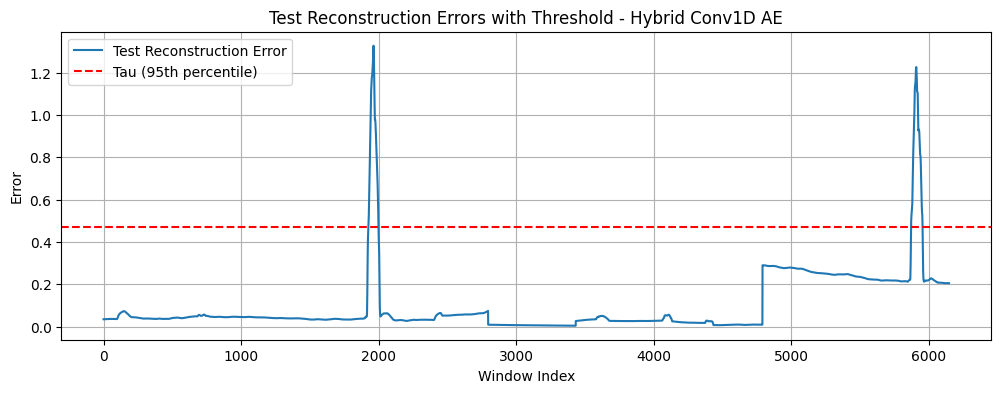

In [62]:
threshold = tau_dict[95]

plt.figure(figsize=(12, 4))
plt.plot(test_reconstruction_errors, label="Test Reconstruction Error")
plt.axhline(threshold, color="red", linestyle="--", label="Tau (95th percentile)")
plt.xlabel("Window Index")
plt.ylabel("Error")
plt.title("Test Reconstruction Errors with Threshold - Hybrid Conv1D AE")
plt.legend()
plt.grid(True)
plt.show()

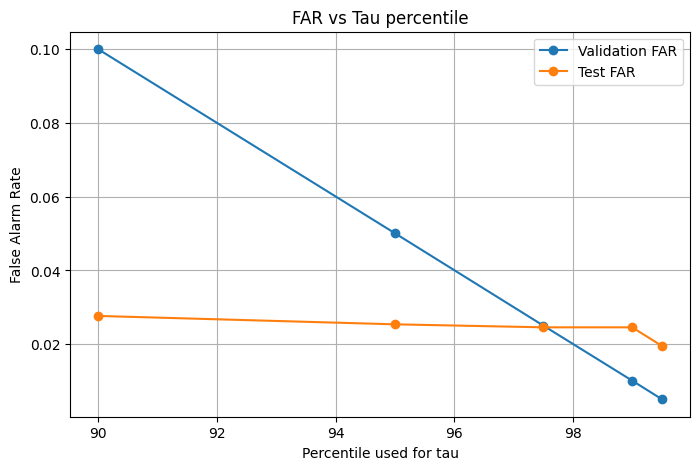

In [63]:
plt.figure(figsize=(8, 5))
plt.plot(far_df["percentile"], far_df["FAR_val"], marker="o", label="Validation FAR")
plt.plot(far_df["percentile"], far_df["FAR_test"], marker="o", label="Test FAR")
plt.xlabel("Percentile used for tau")
plt.ylabel("False Alarm Rate")
plt.title("FAR vs Tau percentile")
plt.grid(True)
plt.legend()
plt.show()

## Guardado de artefactos

In [64]:
import os
import json
import joblib
import pandas as pd
from pathlib import Path
import torch

# =========================
# Configurar nombre del modelo
# =========================
MODEL_NAME = "conv1d_hybrid_ae"

# =========================
# Crear carpetas
# =========================
base_model_dir = Path(f"../models/detectors/{MODEL_NAME}")
base_model_dir.mkdir(parents=True, exist_ok=True)

scaler_dir = Path("../artifacts/scalers")
scaler_dir.mkdir(parents=True, exist_ok=True)

metadata_dir = Path("../artifacts/metadata")
metadata_dir.mkdir(parents=True, exist_ok=True)

metrics_dir = Path("../artifacts/metrics")
metrics_dir.mkdir(parents=True, exist_ok=True)

# =========================
# Guardar pesos del modelo
# =========================
torch.save(model.state_dict(), base_model_dir / "model_state.pt")

# =========================
# Guardar escaladores
# =========================
joblib.dump(scaler_cont, scaler_dir / f"{MODEL_NAME}_scaler_cont.pkl")

# =========================
# Guardar configuración
# =========================
config = {
    "model_name": MODEL_NAME,
    "best_params_from_optuna": BEST_PARAMS,
    "continuous_cols": continuous_cols,
    "discrete_cols": discrete_cols,
    "feature_cols": feature_cols,
    "window_size": L,
    "stride": stride,
    "warmup": WARMUP,
    "seed": SEED,
    "epochs": EPOCHS,
    "batch_size": BATCH_SIZE,
    "loss_function": criterion.__class__.__name__,
    "optimizer": optimizer.__class__.__name__,
    "learning_rate": optimizer.param_groups[0]["lr"],

    # shapes globales por split
    "train_shape": list(train_df.shape),
    "val_shape": list(val_df.shape),
    "test_shape": list(test_df.shape),

    # ventanas separadas
    "train_cont_windows_shape": list(train_cont_windows.shape),
    "val_cont_windows_shape": list(val_cont_windows.shape),
    "test_cont_windows_shape": list(test_cont_windows.shape),

    "train_disc_windows_shape": list(train_disc_windows.shape),
    "val_disc_windows_shape": list(val_disc_windows.shape),
    "test_disc_windows_shape": list(test_disc_windows.shape),

    # inputs finales del modelo
    "X_train_shape": list(X_train.shape),
    "X_val_shape": list(X_val.shape),
    "X_test_shape": list(X_test.shape),

    "X_train_disc_shape": list(X_train_disc.shape),
    "X_val_disc_shape": list(X_val_disc.shape),
    "X_test_disc_shape": list(X_test_disc.shape),

    # resumen discreto
    "train_disc_summary_shape": list(train_disc_summary.shape),
    "val_disc_summary_shape": list(val_disc_summary.shape),
    "test_disc_summary_shape": list(test_disc_summary.shape),
}

with open(base_model_dir / "config.json", "w") as f:
    json.dump(config, f, indent=4)

# =========================
# Guardar taus
# =========================
tau_dict_serializable = {str(k): float(v) for k, v in tau_dict.items()}

with open(base_model_dir / "tau_dict.json", "w") as f:
    json.dump(tau_dict_serializable, f, indent=4)

# =========================
# Guardar métricas
# =========================
if "far_df" in globals():
    far_df.to_csv(base_model_dir / "metrics.csv", index=False)
    far_df.to_csv(metrics_dir / f"{MODEL_NAME}_far.csv", index=False)

# =========================
# Guardar historial de entrenamiento
# =========================
if "loss_history" in globals() and "val_loss_history" in globals():
    loss_df = pd.DataFrame({
        "epoch": list(range(1, len(loss_history) + 1)),
        "train_loss": loss_history,
        "val_loss": val_loss_history
    })
    loss_df.to_csv(base_model_dir / "loss_history.csv", index=False)

print(f"Artefactos guardados correctamente para {MODEL_NAME}")
print(f"Ruta: {base_model_dir.resolve()}")

Artefactos guardados correctamente para conv1d_hybrid_ae
Ruta: D:\Documentos\Uniandes\12 Semestre\PROYECTO DE GRADO\repoPrincipal\ics-synthetic-data-augmentation\models\detectors\conv1d_hybrid_ae
